# Integrated energy grids - Multi-country

## Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
from datetime import timedelta
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
import sys
import importlib
from IPython.display import display

pd.options.display.width = 120

print('pandas', pd.__version__, 'numpy', np.__version__)

pandas 3.0.2 numpy 2.4.3


## Data collection

### Folder Setup

In [2]:
# List files in current directory
print("Current directory:", os.getcwd())
print("\nFiles in workspace:")
for file in os.listdir('.'):
    print(f"  {file}")

Current directory: d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment

Files in workspace:
  .git
  python_codes
  IEG_Course_Project_Part1.pdf
  Data
  Plots
  README.md
  back-up projects
  IEG_Course_Project_Part2.pdf
  IEG_2_Interannual_Variability.ipynb
  IEG_5_Elec_&_H2_&_Heat.ipynb
  IEG_4_Elec_&_H2.ipynb
  IEG_1_Single_country.ipynb
  IEG_3_Multi_country.ipynb
  IEG_6_Elec_&_H2_&_Heat_(Nuclear_Constrained).ipynb


### CSV loading

- **Installed Capacity**
- **Hourly operating program**
- **Daily gas price**

In [3]:
# --- 1) Load CSV data (workspace files) ---
base = Path('./Data')
cap_file = base / 'export_InstalledCapacityGenerationTotal_2026-03-03_17_12.csv'
hourly_file = base / 'export_OperatingHourlyProgramGeneration+Storage+BalearicHVDCLinkP48_2026-03-03_17_22.csv'
gas_file = base / 'Gas prices Spain 2025.csv'

# Read installed capacities
cap_df = pd.read_csv(cap_file, sep=';')
cap_df = cap_df.rename(columns={'name':'tech','value':'capacity','start_date':'start','end_date':'end'})
print('installed capacities rows:', len(cap_df))
display(cap_df.head())

# Read hourly operating program (we treat 'value' as system demand/required generation)
hourly_df = pd.read_csv(hourly_file, sep=';')
hourly_df['datetime'] = pd.to_datetime(hourly_df['datetime'], utc=True)
hourly_df = hourly_df.set_index('datetime').sort_index()
print('hourly rows:', len(hourly_df))
display(hourly_df.head(3))

# Read gas price (daily)
gas_df = pd.read_csv(gas_file, sep=';', header=0)
# Clean up columns and decimals
gas_df.columns = [c.strip('"') for c in gas_df.columns]
gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)
gas_df['MIBGAS-ES Index'] = gas_df['MIBGAS-ES Index'].astype(str).str.replace(',', '.').astype(float)
gas_df = gas_df.set_index('Delivery Day')['MIBGAS-ES Index']
display(gas_df.head(3))

installed capacities rows: 27


,id,tech,geoid,geoname,capacity,start,end
0,1478,Installed capacity generation coal,NaN,NaN,241.200,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
1,1478,Installed capacity generation coal,NaN,NaN,570.050,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
2,1478,Installed capacity generation coal,NaN,NaN,1249.925,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
3,1483,Installed capacity generation combined cycle GT,NaN,NaN,26250.145,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
4,1489,Installed capacity generation cogeneration,NaN,NaN,5622.455,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00


hourly rows: 188498


,id,name,geoid,geoname,value
datetime,,,,,
2023-12-31 23:00:00+00:00,10024,Operating Hourly Program Generation + storage ...,NaN,NaN,21453.375
2023-12-31 23:00:00+00:00,92,Operating Hourly Program P48 Biogas,NaN,NaN,82.500
2023-12-31 23:00:00+00:00,91,Operating Hourly Program P48 Biomass,NaN,NaN,207.600


C:\Users\ccano\AppData\Local\Temp\ipykernel_33428\2052013660.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)


Delivery Day
2025-03-03    46.23
2025-03-04    44.69
2025-03-05    43.07
Name: MIBGAS-ES Index, dtype: float64

**Compilation of installed capacity**

In [4]:
# --- 2) Compile capacities by technology ---
cap_by_tech = cap_df.groupby('tech', dropna=False)['capacity'].sum().to_frame()
# Map long names to short technology keys (edit mapping as needed)
tech_map = {
    'Installed capacity generation combined cycle GT': 'CCGT',
    'Installed capacity generation coal': 'Coal',
    'Installed capacity generation nuclear': 'Nuclear',
    'Installed capacity generation wind': 'Wind',
    'Installed capacity generation hydro': 'Hydro',
    'Installed capacity generation solar': 'Solar',
    'Installed capacity generation solar PV': 'Solar',
    'Installed capacity generation solar thermal': 'Solar',
    'Installed capacity generation diesel engines': 'Diesel',
    'Installed capacity generation cogeneration': 'CHP',
    'Installed capacity generation other renewables': 'OtherRenew'
}
tech_caps = {}
for longname, cap in cap_by_tech['capacity'].items():
    key = tech_map.get(longname, longname)
    tech_caps[key] = tech_caps.get(key, 0.0) + float(cap)

# Filter to only Wind, Solar, and Hydro
tech_caps = {k: v for k, v in tech_caps.items() if k in ['Wind', 'Solar', 'Hydro']}
tech_caps = pd.Series(tech_caps).sort_values(ascending=False)
print('Aggregated technology capacities (MW):')
display(tech_caps)

Aggregated technology capacities (MW):


Solar    33947.119
Wind     31020.198
Hydro    17096.959
dtype: float64

**Hourly Demand Set-up**

In [5]:
# --- 3) Prepare hourly demand and hourly gas price series ---
demand = hourly_df['value'].rename('demand')
# Expand daily gas price to hourly (forward-fill)
# build hourly index covering demand range
hour_index = pd.date_range(start=demand.index[0].floor('D'), end=demand.index[-1].ceil('D') - timedelta(hours=1), freq='h')
print('demand range:', demand.index.min(), 'to', demand.index.max())
display(demand.head())

demand range: 2023-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00


datetime
2023-12-31 23:00:00+00:00    21453.375
2023-12-31 23:00:00+00:00       82.500
2023-12-31 23:00:00+00:00      207.600
2023-12-31 23:00:00+00:00        2.800
2023-12-31 23:00:00+00:00     3341.100
Name: demand, dtype: float64

**Generation by technology dataframe creation**

In [6]:
# Read full hourly file (raw multiple technologies)
df_raw = pd.read_csv(hourly_file, sep=';')
# parse datetimes
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], utc=True)

# helper to simplify long technology names
def simplify_name(n: str) -> str:
    # handle NaN or non-string
    if pd.isna(n):
        return 'Other'
    s = str(n).lower().strip()
    if not s:
        return 'Other'
    # Remove common prefixes/words that add noise
    for drop in ['operating hourly program', 'operating hourly program generation', 'operating hourly program p48', 'operating hourly program p48 ', 'p48', 'balearic', 'hvdc link', '+', '/', '\\n']:
        s = s.replace(drop, ' ')
    s = ' '.join(s.split())
    # mapping by keywords
    if 'hydro' in s:
        return 'Hydro'
    if 'wind' in s:
        return 'Wind'
    if 'solar' in s or 'pv' in s:
        return 'Solar'
    if 'coal' in s:
        return 'Coal'
    if 'nuclear' in s:
        return 'Nuclear'
    if 'combined cycle' in s or 'ccgt' in s or 'combined' in s:
        return 'CCGT'
    if 'diesel' in s or 'diesel engines' in s:
        return 'Diesel'
    if 'cogeneration' in s or 'chp' in s:
        return 'CHP'
    if 'storage' in s or 'battery' in s or 'pumping' in s or 'turbine pumping' in s or 'pump' in s:
        return 'Storage'
    if 'hvdc' in s or 'link' in s:
        return 'HVDC'
    if 'waste' in s:
        return 'Waste'
    if 'other' in s or 'renew' in s:
        return 'OtherRenew'
    # fallback: take first meaningful token
    toks = [t for t in s.split() if any(c.isalpha() for c in t)]
    if toks:
        tok = toks[0]
        return tok.capitalize()
    return 'Other'

# Apply simplification
if 'name' not in df_raw.columns:
    df_raw['name'] = 'Unknown'

df_raw['tech'] = df_raw['name'].apply(simplify_name)

# Keep only relevant columns
df_small = df_raw[['datetime', 'tech', 'value']].copy()
# convert value to numeric
df_small['value'] = pd.to_numeric(df_small['value'], errors='coerce').fillna(0.0)

# Pivot: index=datetime, columns=tech, aggregate by sum (some hours may have multiple rows per tech)
gen_by_tech = df_small.pivot_table(index='datetime', columns='tech', values='value', aggfunc='sum')

# drop storage column entirely if present
if 'Storage' in gen_by_tech.columns:
    gen_by_tech = gen_by_tech.drop(columns=['Storage'])

# ensure non‑negative
gen_by_tech = gen_by_tech.clip(lower=0)

# Ensure full hourly index covering the range of 2024 data present in CSV
full_index = pd.date_range(start=gen_by_tech.index.min().floor('D'), end=gen_by_tech.index.max().ceil('D') - pd.Timedelta(hours=1), freq='h')
gen_by_tech = gen_by_tech.reindex(full_index).fillna(0.0)
# set name for index
gen_by_tech.index.name = 'datetime'

# add demand column equal to sum of technologies (excluding negative values)
gen_by_tech['demand'] = gen_by_tech.clip(lower=0).sum(axis=1)

print('Generated DataFrame `gen_by_tech` with shape:', gen_by_tech.shape)
display(gen_by_tech.head())

# Save to csv for later use
gen_by_tech.to_csv('./Data/generation_by_tech_2024.csv')


Generated DataFrame `gen_by_tech` with shape: (8808, 18)


tech,Biogas,Biomass,CCGT,CHP,Coal,Fossil,Generic,Hydro,Mining,Nuclear,Other,OtherRenew,Residual,Scheduled,Solar,Waste,Wind,demand
datetime,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 03:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 04:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Sample week**

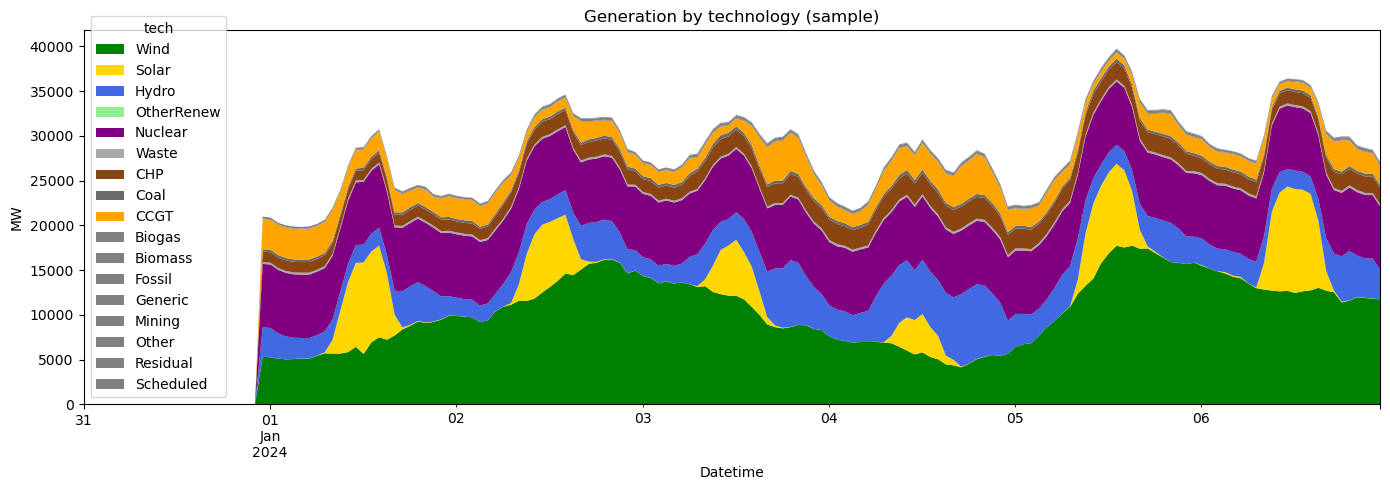

In [7]:
# --- Plot `gen_by_tech` (stacked area) ---
import matplotlib.pyplot as plt

if 'gen_by_tech' not in globals():
    raise RuntimeError('`gen_by_tech` not found. Run the earlier cell that constructs it first.')

# choose sample length (first week = 168 hours) for readability
sample_hours = 168
sample = gen_by_tech.iloc[:sample_hours] if len(gen_by_tech) >= sample_hours else gen_by_tech

# drop the demand column before plotting
plot_df = sample.drop(columns=['demand'], errors='ignore')

# define a consistent color mapping for technologies
color_map = {
    'Wind': 'green',
    'Solar': 'gold',
    'Hydro': 'royalblue',
    'Coal': 'dimgray',
    'Nuclear': 'purple',
    'Diesel': 'red',
    'CCGT': 'orange',
    'CHP': 'saddlebrown',
    'HVDC': 'black',
    'OtherRenew': 'lightgreen',
    'Waste': 'darkgray'
}

# Order technologies by cost (cheapest at bottom, most expensive at top)
# This order is based on typical marginal costs
tech_cost_order = ['Wind', 'Solar', 'Hydro', 'OtherRenew', 'Nuclear', 'Waste', 'HVDC', 'CHP', 'Coal', 'CCGT', 'Diesel']
ordered_cols = [col for col in tech_cost_order if col in plot_df.columns]
# Add any remaining columns not in the order list
ordered_cols += [col for col in plot_df.columns if col not in ordered_cols]
plot_df = plot_df[ordered_cols]

# pick colors in the order of plot columns; fallback to gray if not mapped
colors = [color_map.get(col, 'gray') for col in plot_df.columns]


ax = plot_df.plot.area(figsize=(14,5), linewidth=0, color=colors)

ax.set_title('Generation by technology (sample)')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
plt.tight_layout()
plt.show()

**Renewable energy limits and Demand for the optimization**

Wind capacity: 31020.20 MW
Solar capacity: 33947.12 MW
Hydro capacity: 17096.96 MW

Winter: found 12 full weeks
Winter week range: 2024-01-14 00:00:00+00:00 to 2024-01-20 23:00:00+00:00

Summer: found 13 full weeks
Summer week range: 2024-07-06 00:00:00+00:00 to 2024-07-12 23:00:00+00:00



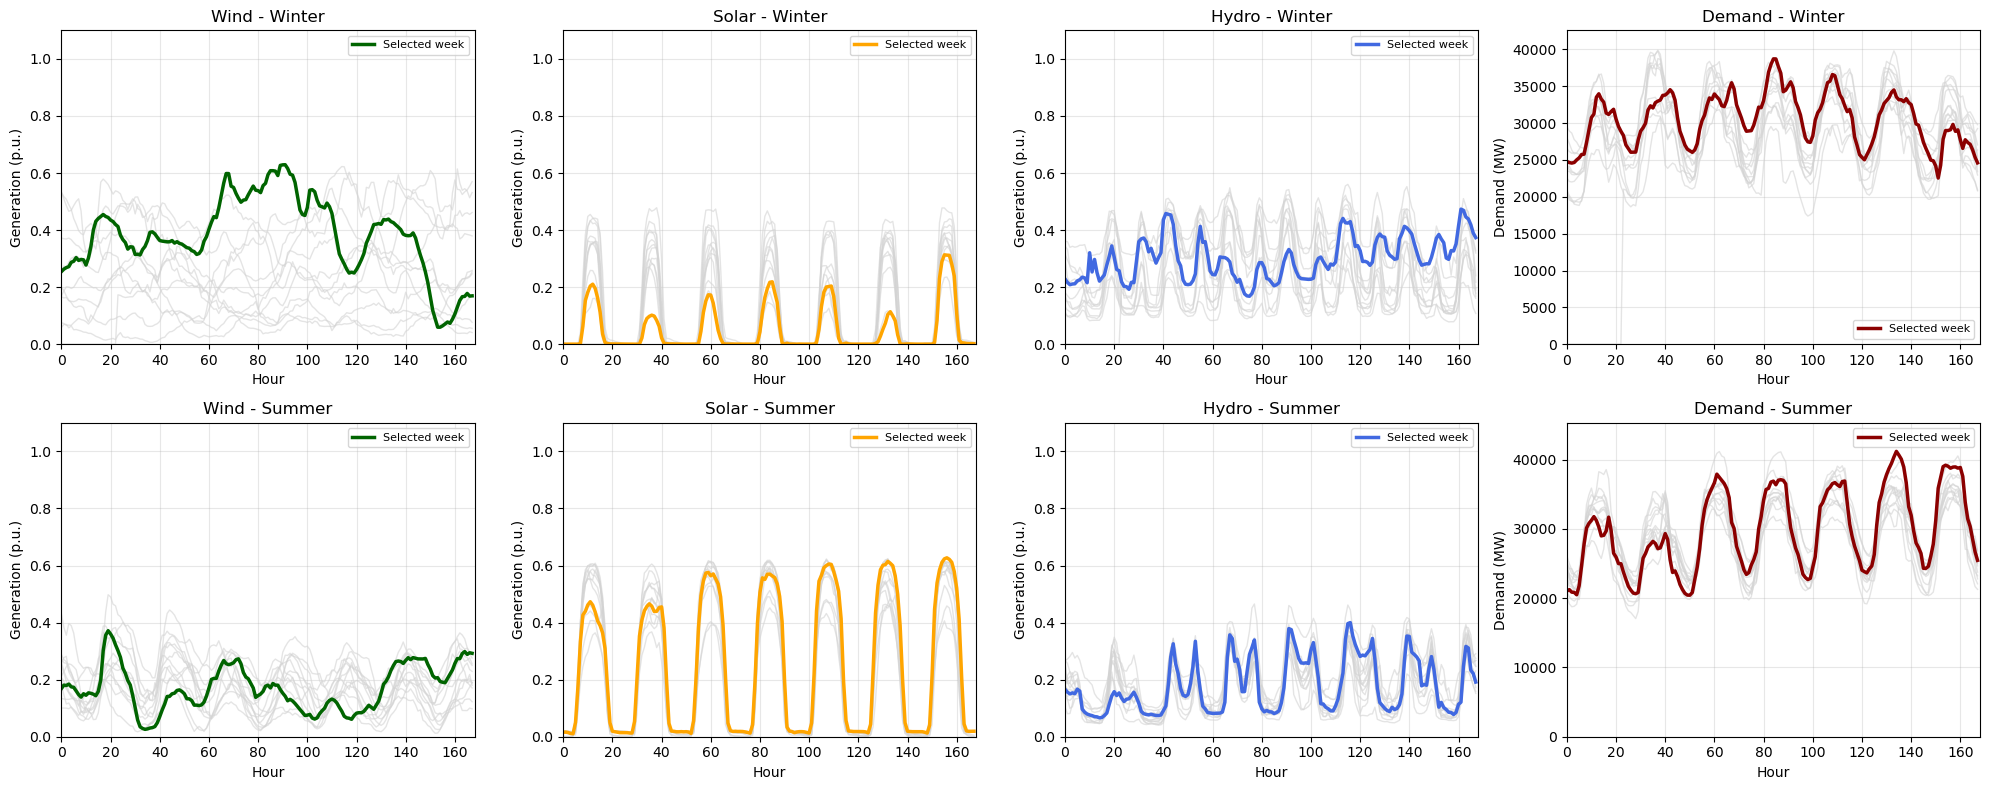

In [8]:
# --- Calculate p.u. generation for Wind, Solar, and Hydro + Demand ---
season_months = {
    'Winter': [12, 1, 2],
    'Summer': [6, 7, 8]
}

# Get capacities for p.u. calculation
wind_cap = tech_caps.get('Wind', 1.0)
solar_cap = tech_caps.get('Solar', 1.0)
hydro_cap = tech_caps.get('Hydro', 1.0)

print(f"Wind capacity: {wind_cap:.2f} MW")
print(f"Solar capacity: {solar_cap:.2f} MW")
print(f"Hydro capacity: {hydro_cap:.2f} MW\n")

# Store all weekly data and random selection per season
all_weekly_data = {}
pu_gen = {}

for season, months in season_months.items():
    # Subset data for season
    gb = gen_by_tech.copy()
    season_data = gb[gb.index.month.isin(months)]
    
    # Extract 7-day windows
    weekly = []
    start = season_data.index[0].floor('D')
    end = season_data.index[-1].ceil('D')
    current = start
    while current + pd.Timedelta(days=7) <= end:
        week_slice = season_data.loc[current:current + pd.Timedelta(days=7) - pd.Timedelta(hours=1)]
        if len(week_slice) == 168:
            weekly.append(week_slice)
        current += pd.Timedelta(days=7)
    
    print(f"{season}: found {len(weekly)} full weeks")
    
    # Store all weeks' p.u. data and demand
    all_weekly_data[season] = {'Wind': [], 'Solar': [], 'Hydro': [], 'Demand': []}
    for week_data in weekly:
        all_weekly_data[season]['Wind'].append(week_data.get('Wind', pd.Series(0, index=week_data.index)).values / wind_cap)
        all_weekly_data[season]['Solar'].append(week_data.get('Solar', pd.Series(0, index=week_data.index)).values / solar_cap)
        all_weekly_data[season]['Hydro'].append(week_data.get('Hydro', pd.Series(0, index=week_data.index)).values / hydro_cap)
        all_weekly_data[season]['Demand'].append(week_data.get('demand', pd.Series(0, index=week_data.index)).values)
    
    # Select random week
    if weekly:
        random_idx = np.random.randint(0, len(weekly))
        random_week = weekly[random_idx]
        
        # Store random week data
        pu_gen[season] = pd.DataFrame(index=random_week.index)
        pu_gen[season]['Wind'] = random_week.get('Wind', pd.Series(0, index=random_week.index)) / wind_cap
        pu_gen[season]['Solar'] = random_week.get('Solar', pd.Series(0, index=random_week.index)) / solar_cap
        pu_gen[season]['Hydro'] = random_week.get('Hydro', pd.Series(0, index=random_week.index)) / hydro_cap
        pu_gen[season]['Demand'] = random_week.get('demand', pd.Series(0, index=random_week.index))
        
        print(f"{season} week range: {random_week.index[0]} to {random_week.index[-1]}\n")

# Plot p.u. generation and demand for random weeks with all weeks in background
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

colors = {'Wind': 'darkgreen', 'Solar': 'orange', 'Hydro': 'royalblue', 'Demand': 'darkred'}

# Calculate common x-axis limits
x_max = max(len(data) for data in pu_gen.values())

for row, (season, data) in enumerate(pu_gen.items()):
    for col, tech in enumerate(['Wind', 'Solar', 'Hydro', 'Demand']):
        ax = axes[row, col]
        
        # Plot all weeks in light grey
        for week_profile in all_weekly_data[season][tech]:
            ax.plot(range(len(week_profile)), week_profile, 
                    color='lightgrey', linewidth=1.0, alpha=0.6)
        
        # Overlay random week in bold color
        ax.plot(range(len(data)), data[tech].values, 
                color=colors[tech], linewidth=2.5, label='Selected week')
        
        ax.set_title(f"{tech} - {season}")
        if tech == 'Demand':
            ax.set_ylabel('Demand (MW)')
            ax.set_ylim([0, max(data[tech].values) * 1.1])
        else:
            ax.set_ylabel('Generation (p.u.)')
            ax.set_ylim([0, 1.1])
        ax.set_xlabel('Hour')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, x_max])
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

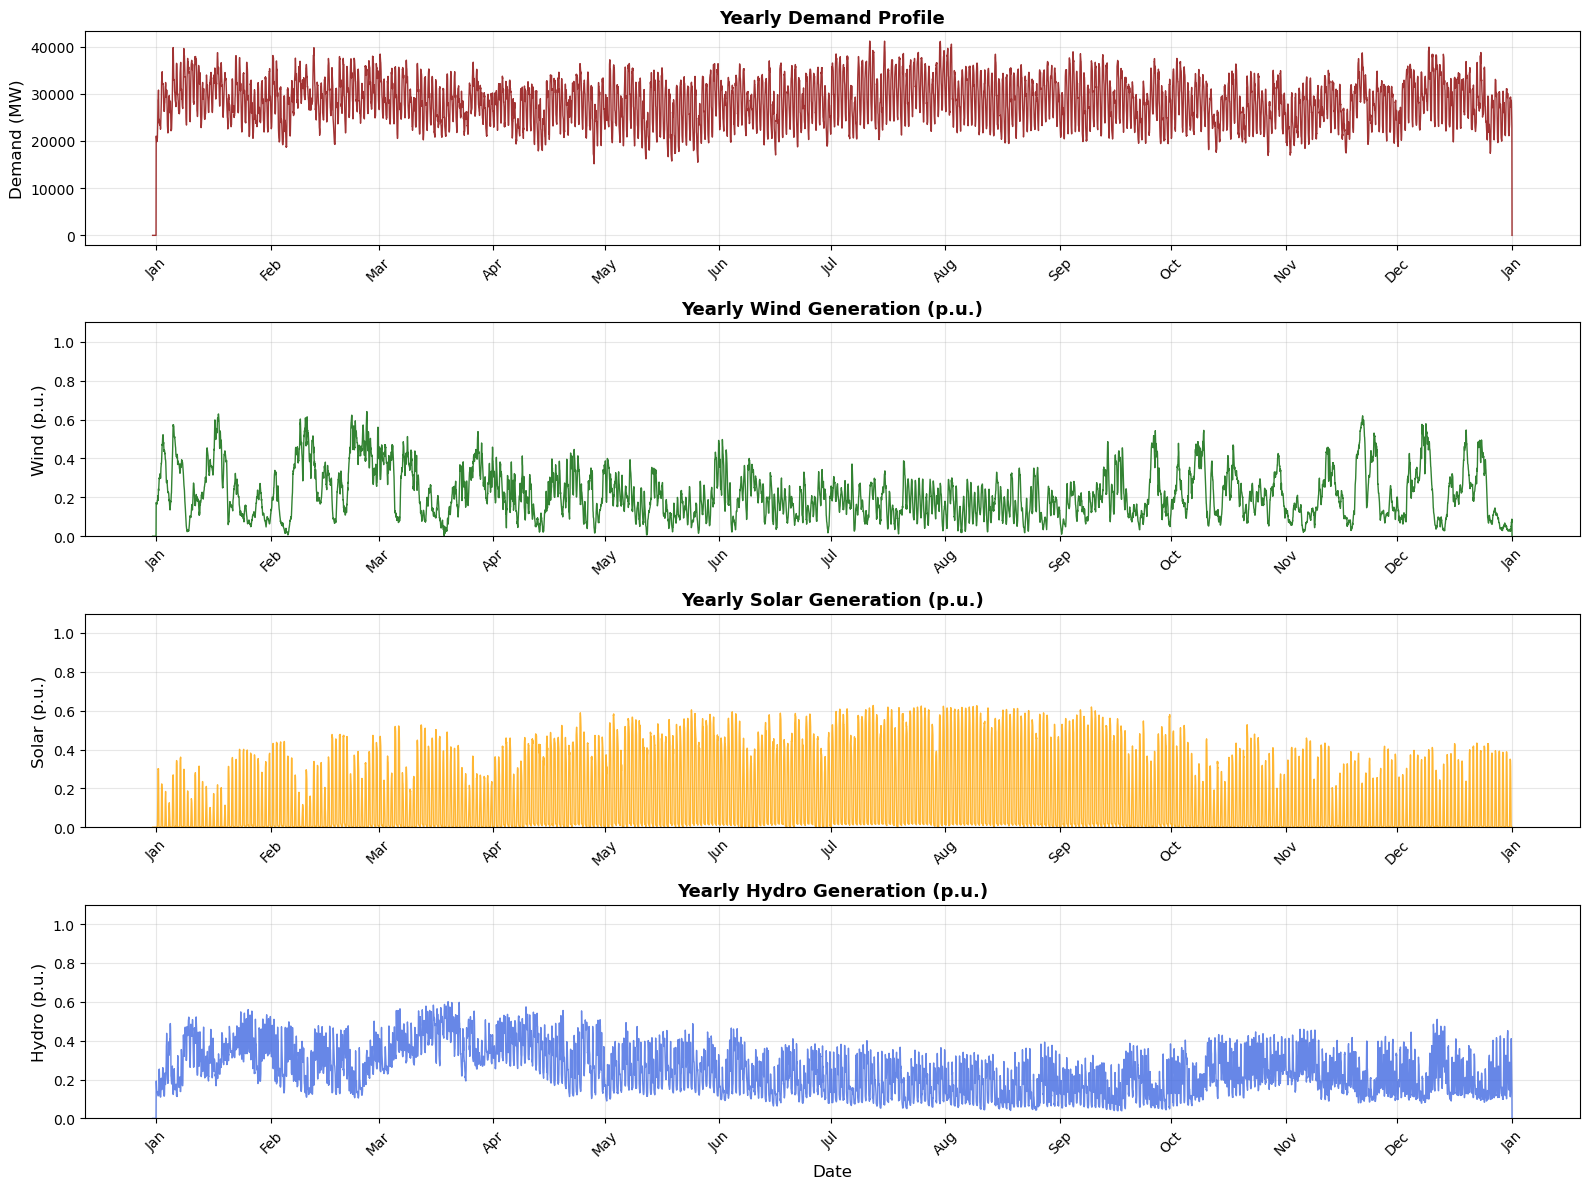

Demand (MW):
  Average: 28246.14
  Peak: 41177.93
  Min: 0.00

Wind Generation (p.u.):
  Average: 0.216
  Peak: 0.641
  Min: 0.000

Solar Generation (p.u.):
  Average: 0.161
  Peak: 0.627
  Min: 0.000

Hydro Generation (p.u.):
  Average: 0.240
  Peak: 0.601
  Min: 0.000


In [9]:
# Plot yearly Demand + Solar, Wind, and Hydro in p.u.
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Calculate p.u. values for each technology
wind_pu = gen_by_tech['Wind'] / wind_cap
solar_pu = gen_by_tech['Solar'] / solar_cap
hydro_pu = gen_by_tech['Hydro'] / hydro_cap
yearly_demand = gen_by_tech['demand']

# Plot Demand
axes[0].plot(yearly_demand.index, yearly_demand.values, color='darkred', linewidth=1, alpha=0.8)
axes[0].set_ylabel('Demand (MW)', fontsize=12)
axes[0].set_title('Yearly Demand Profile', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot Wind
axes[1].plot(wind_pu.index, wind_pu.values, color='darkgreen', linewidth=1, alpha=0.8)
axes[1].set_ylabel('Wind (p.u.)', fontsize=12)
axes[1].set_title('Yearly Wind Generation (p.u.)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.1])

# Plot Solar
axes[2].plot(solar_pu.index, solar_pu.values, color='orange', linewidth=1, alpha=0.8)
axes[2].set_ylabel('Solar (p.u.)', fontsize=12)
axes[2].set_title('Yearly Solar Generation (p.u.)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.1])

# Plot Hydro
axes[3].plot(hydro_pu.index, hydro_pu.values, color='royalblue', linewidth=1, alpha=0.8)
axes[3].set_ylabel('Hydro (p.u.)', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)
axes[3].set_title('Yearly Hydro Generation (p.u.)', fontsize=13, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim([0, 1.1])

# Format x-axis to show months for all subplots
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Print statistics
print("Demand (MW):")
print(f"  Average: {yearly_demand.mean():.2f}")
print(f"  Peak: {yearly_demand.max():.2f}")
print(f"  Min: {yearly_demand.min():.2f}\n")

print("Wind Generation (p.u.):")
print(f"  Average: {wind_pu.mean():.3f}")
print(f"  Peak: {wind_pu.max():.3f}")
print(f"  Min: {wind_pu.min():.3f}\n")

print("Solar Generation (p.u.):")
print(f"  Average: {solar_pu.mean():.3f}")
print(f"  Peak: {solar_pu.max():.3f}")
print(f"  Min: {solar_pu.min():.3f}\n")

print("Hydro Generation (p.u.):")
print(f"  Average: {hydro_pu.mean():.3f}")
print(f"  Peak: {hydro_pu.max():.3f}")
print(f"  Min: {hydro_pu.min():.3f}")

In [10]:
# =====================
# 5) Geographic Flow Map (Folium with Capacities)
# =====================
print("\n" + "="*70)
print("GEOGRAPHIC POWER FLOW MAP")
print("="*70)

try:
    import folium
    from folium import plugins
    from IPython.display import HTML
    
    # Bus coordinates (latitude, longitude)
    bus_coords = {
        "ES": (40.4637, -3.7492),      # Madrid area
        "FR": (48.8566, 2.3522),      # Paris area
        "IT": (41.9028, 12.4964),      # Rome area
        "PT": (38.7223, -9.1393)    # Lisbon area
    }
    
    # Network connections: (source, target, NTC_MW)
    power_flows = [
        ("ES", "FR", 3500),
        ("FR", "IT", 4500),
        ("ES", "IT", 2000),
        ("ES", "PT", 4500)
    ]
    
    # Create base map centered on Europe
    center_lat = sum(coord[0] for coord in bus_coords.values()) / len(bus_coords)
    center_lon = sum(coord[1] for coord in bus_coords.values()) / len(bus_coords)
    
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=5,
        tiles='OpenStreetMap',
        prefer_canvas=True
    )
    
    # Plot network connections with simple dash separators
    for source, target, flow_mw in power_flows:
        lat0, lon0 = bus_coords[source]
        lat1, lon1 = bus_coords[target]
        
        # Draw connection line (simple black line)
        folium.PolyLine(
            locations=[[lat0, lon0], [lat1, lon1]],
            color='black',
            weight=2,
            opacity=0.8,
            popup=f"<b>{source} - {target}</b><br>NTC: {flow_mw} MW",
            tooltip=f"{source} - {target}"
        ).add_to(m)
        
        # Add dash separator at midpoint
        mid_lat = (lat0 + lat1) / 2
        mid_lon = (lon0 + lon1) / 2
        
        label_html = f'''
        <div style="font-size: 16px; font-weight: bold; color: black; 
                    text-shadow: -1px -1px 1px white, 1px -1px 1px white, -1px 1px 1px white, 1px 1px 1px white;
                    background-color: rgba(255,255,255,0.75); padding: 4px 6px; border-radius: 3px; white-space: nowrap;">
        {source} - {target} {flow_mw} MW
        </div>
        '''
        
        folium.Marker(
            location=[mid_lat, mid_lon],
            icon=folium.DivIcon(html=label_html),
            popup=f"<b>{source} - {target}</b><br>NTC: {flow_mw} MW"
        ).add_to(m)
    
    # Plot substations (nodes) with larger markers
    for bus_name in bus_coords.keys():
        lat, lon = bus_coords[bus_name]
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=25,
            popup=f"<b>{bus_name}</b><br>400 kV Substation",
            tooltip=bus_name,
            color='#c92a2a',
            fill=True,
            fillColor='#ff6b6b',
            fillOpacity=0.95,
            weight=4,
            zindex=100
        ).add_to(m)
        
        # Add country label
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(html=f'''
            <div style="font-size: 12px; font-weight: bold; color: white;">
            {bus_name}
            </div>
            '''),
            popup=f"{bus_name} - 400 kV AC"
        ).add_to(m)
    
    # Add title with legend
    title_html = '''
    <div style="position: fixed; 
                top: 10px; left: 50px; width: 360px; height: auto;
                background-color: white; border:2px solid #333; z-index:9999; 
                font-size: 12px; padding: 10px; border-radius: 5px;
                box-shadow: 0 0 10px rgba(0,0,0,0.2);">
    <b style="font-size: 13px;">Network Capacity: 400 kV AC</b><br>
    <span style="font-size: 10px; color: #666;">Lines show NTC capacity</span><br>
    <div style="font-size: 10px; margin-top: 6px; line-height: 1.4;">
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    # Display the map
    print("✓ Geographic capacity map created successfully!")
    display(HTML(m._repr_html_()))
    
except ImportError:
    print("Folium not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'folium', '-q'])
    print("Folium installed. Please rerun this cell.")
    
except Exception as e:
    print(f"Error: {type(e).__name__}: {str(e)}")
    print("Could not create geographic capacity map.")


GEOGRAPHIC POWER FLOW MAP
✓ Geographic capacity map created successfully!


In [11]:
# --- Load generation data for each country ---
import pandas as pd
import numpy as np
from pathlib import Path

countries_data_path = Path('./Data/Countries interconnected Data')

# Dictionary to store generation by tech for each country
gen_by_tech_countries = {}

# Country mapping
country_files = {
    'France': 'France_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
    'Italy': 'Italy_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
    'Portugal': 'Portugal_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
}

for country, filename in country_files.items():
    filepath = countries_data_path / filename
    
    # Read the CSV
    df = pd.read_csv(filepath, sep=';')
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Parse timestamp column to extract datetime
    # Format: "01/01/2024 00:00:00 - 01/01/2024 01:00:00" (may have timezone like " (CET)")
    # Extract start time and remove any trailing timezone info
    timestep_start = df['Timestep'].str.split(' - ', n=1, expand=True, regex=False)[0]
    timestep_clean = timestep_start.str.split(' (', n=1, expand=True, regex=False)[0]
    df['datetime'] = pd.to_datetime(timestep_clean, format='%d/%m/%Y %H:%M:%S')
    
    # Function to clean values (convert 'n/e' and other non-numeric to 0)
    def clean_value(val):
        if pd.isna(val):
            return 0.0
        s = str(val).strip().lower()
        if s in ['n/e', 'n/a', '']:
            return 0.0
        try:
            return float(val)
        except:
            return 0.0
    
    # Extract and aggregate wind (Onshore + Offshore)
    wind_onshore = df.loc[:, 'Wind Onshore (MW)'].apply(clean_value).values
    wind_offshore = df.loc[:, 'Wind Offshore (MW)'].apply(clean_value).values
    wind = wind_onshore + wind_offshore
    
    # Extract solar
    solar = df.loc[:, 'Solar (MW)'].apply(clean_value).values
    
    # Extract hydro (Reservoir + Run-of-river & pondage)
    # Note: Excluding pumped storage as it's not main generation
    hydro_reservoir = df.loc[:, 'Hydro Water Reservoir (MW)'].apply(clean_value).values
    hydro_runofriver = df.loc[:, 'Hydro Run-of-river and pondage (MW)'].apply(clean_value).values
    hydro = hydro_reservoir + hydro_runofriver
    
    # Extract nuclear and fossil fuel generation
    nuclear = df.loc[:, 'Nuclear (MW)'].apply(clean_value).values
    coal = df.loc[:, 'Fossil Hard coal (MW)'].apply(clean_value).values
    fossil_gas = df.loc[:, 'Fossil Gas (MW)'].apply(clean_value).values
    
    # Create generation by tech dataframe (before setting index to handle duplicates)
    gen_df = pd.DataFrame({
        'datetime': df['datetime'],
        'Wind': wind,
        'Solar': solar,
        'Hydro': hydro,
        'Nuclear': nuclear,
        'Coal': coal,
        'Fossil Gas': fossil_gas,
    })
    
    # Handle duplicate timestamps by taking the mean (in case of DST transitions)
    gen_by_tech = gen_df.groupby('datetime').mean()
    gen_by_tech.index.name = 'datetime'
    
    # Ensure hourly frequency (reindex to fill any gaps)
    full_index = pd.date_range(
        start=gen_by_tech.index.min().floor('D'),
        end=gen_by_tech.index.max().ceil('D') - pd.Timedelta(hours=1),
        freq='h'
    )
    gen_by_tech = gen_by_tech.reindex(full_index).fillna(0.0)
    gen_by_tech.index.name = 'datetime'
    
    # Add demand as sum of all generation
    gen_by_tech['demand'] = gen_by_tech[['Wind', 'Solar', 'Hydro', 'Nuclear', 'Coal', 'Fossil Gas']].sum(axis=1)
    
    gen_by_tech_countries[country] = gen_by_tech
    
    print(f"\n{country}:")
    print(f"  Shape: {gen_by_tech.shape}")
    print(f"  Date range: {gen_by_tech.index.min()} to {gen_by_tech.index.max()}")
    print(f"  Average demand: {gen_by_tech['demand'].mean():.1f} MW")
    display(gen_by_tech.head())


France:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 58104.5 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,14977.0,225.0,6303.0,40387.0,15.0,1810.0,63717.0
2024-01-01 01:00:00,14734.0,0.0,6049.0,37528.0,16.0,1840.0,60167.0
2024-01-01 02:00:00,14367.0,0.0,5923.0,37320.0,16.0,1787.0,59413.0
2024-01-01 03:00:00,13393.0,0.0,5812.0,36954.0,15.0,1778.0,57952.0
2024-01-01 04:00:00,8607.0,0.0,5661.0,36906.0,15.0,1765.0,52954.0



Italy:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 21994.3 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,3905.0,0.0,2358.0,0.0,423.0,8652.0,15338.0
2024-01-01 01:00:00,3927.0,0.0,2195.0,0.0,424.0,7679.0,14225.0
2024-01-01 02:00:00,4041.0,0.0,2051.0,0.0,424.0,6774.0,13290.0
2024-01-01 03:00:00,4122.0,0.0,2008.0,0.0,424.0,6516.0,13070.0
2024-01-01 04:00:00,4018.0,0.0,1912.0,0.0,424.0,6308.0,12662.0



Portugal:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 4095.9 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,351.9,0.1,902.2,0.0,0.0,190.9,1445.1
2024-01-01 01:00:00,342.7,0.0,776.0,0.0,0.0,192.7,1311.4
2024-01-01 02:00:00,413.9,0.0,643.4,0.0,0.0,190.1,1247.4
2024-01-01 03:00:00,487.1,0.0,1239.3,0.0,0.0,189.7,1916.1
2024-01-01 04:00:00,510.7,0.0,930.5,0.0,0.0,189.9,1631.1



MULTI-COUNTRY P.U. GENERATION ANALYSIS - FULL YEAR


Processing: Spain (p.u. data already available)

Data range: 2023-12-31 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
Total hours: 8808 hours

Demand Statistics:
  Average: 28,246 MW
  Peak: 41,178 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.216 (21.6%)
  Solar: 0.161 (16.1%)
  Hydro: 0.240 (24.0%)


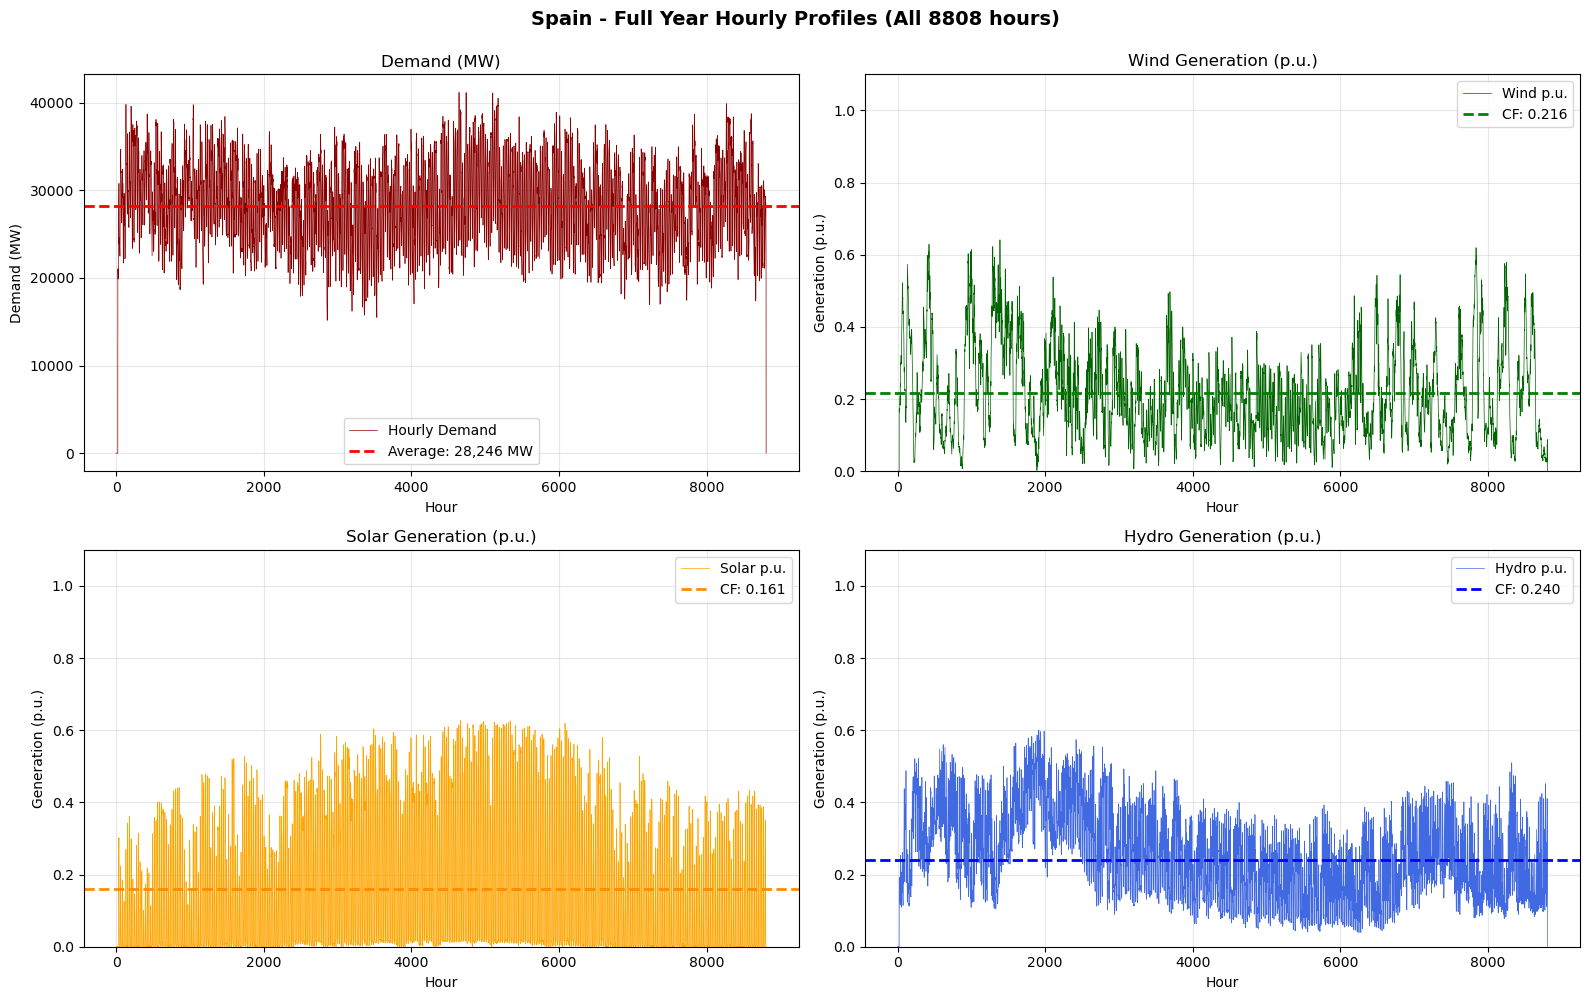


✓ Spain full-year plots completed

Installed capacities for other countries (MW):
  France: Wind=24,500, Solar=20,000, Hydro=25,500
  Italy: Wind=13,600, Solar=37,500, Hydro=22,089
  Portugal: Wind=6,000, Solar=3,500, Hydro=7,200


Processing: France

Installed capacity (p.u. basis):
  Wind: 24,500 MW
  Solar: 20,000 MW
  Hydro: 25,500 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 58,105 MW
  Peak: 81,066 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.213 (21.3%)
  Solar: 0.133 (13.3%)
  Hydro: 0.283 (28.3%)


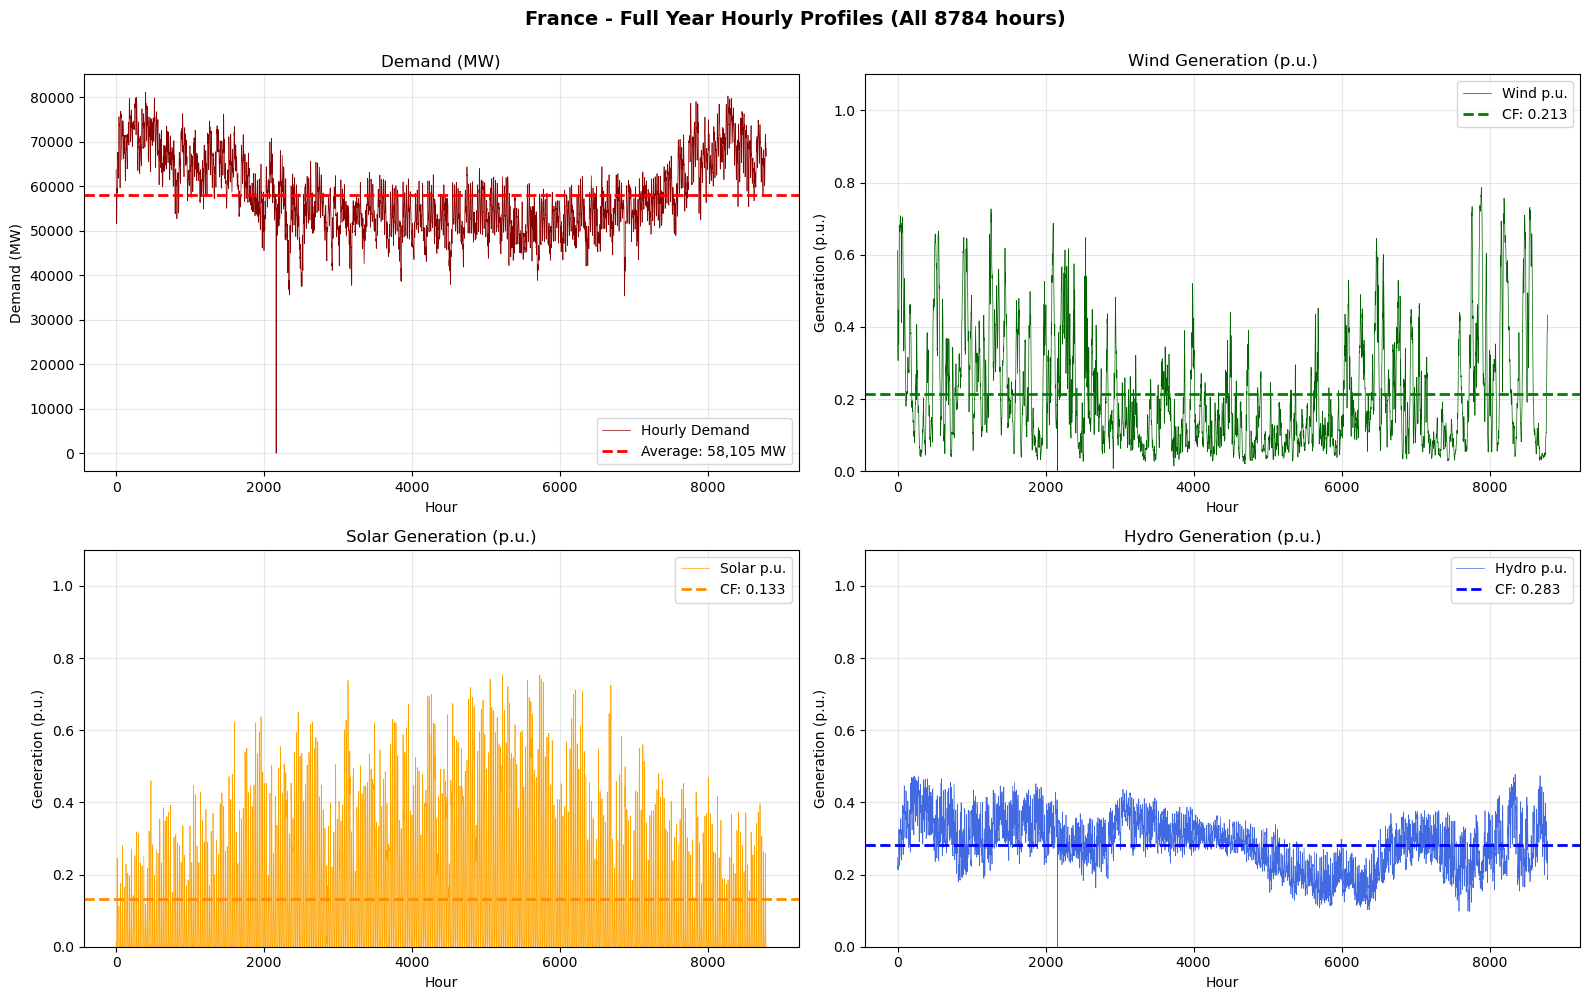


✓ France full-year plots completed


Processing: Italy

Installed capacity (p.u. basis):
  Wind: 13,600 MW
  Solar: 37,500 MW
  Hydro: 22,089 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 21,994 MW
  Peak: 41,529 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.184 (18.4%)
  Solar: 0.084 (8.4%)
  Hydro: 0.238 (23.8%)


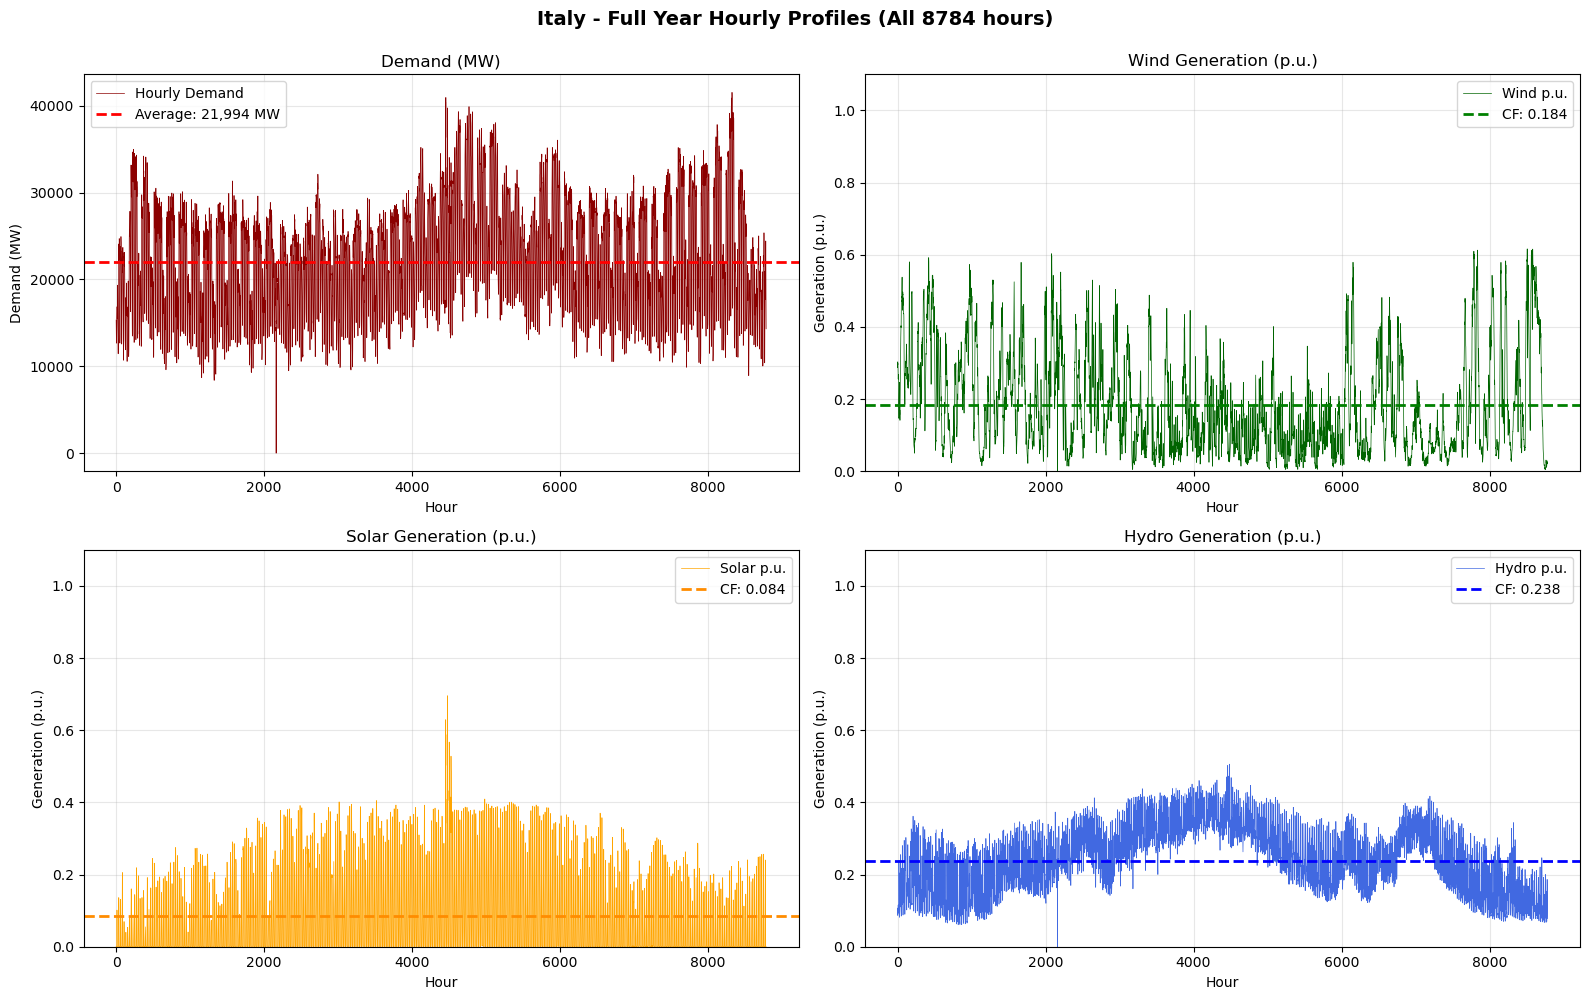


✓ Italy full-year plots completed


Processing: Portugal

Installed capacity (p.u. basis):
  Wind: 6,000 MW
  Solar: 3,500 MW
  Hydro: 7,200 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 4,096 MW
  Peak: 9,674 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.268 (26.8%)
  Solar: 0.160 (16.0%)
  Hydro: 0.190 (19.0%)


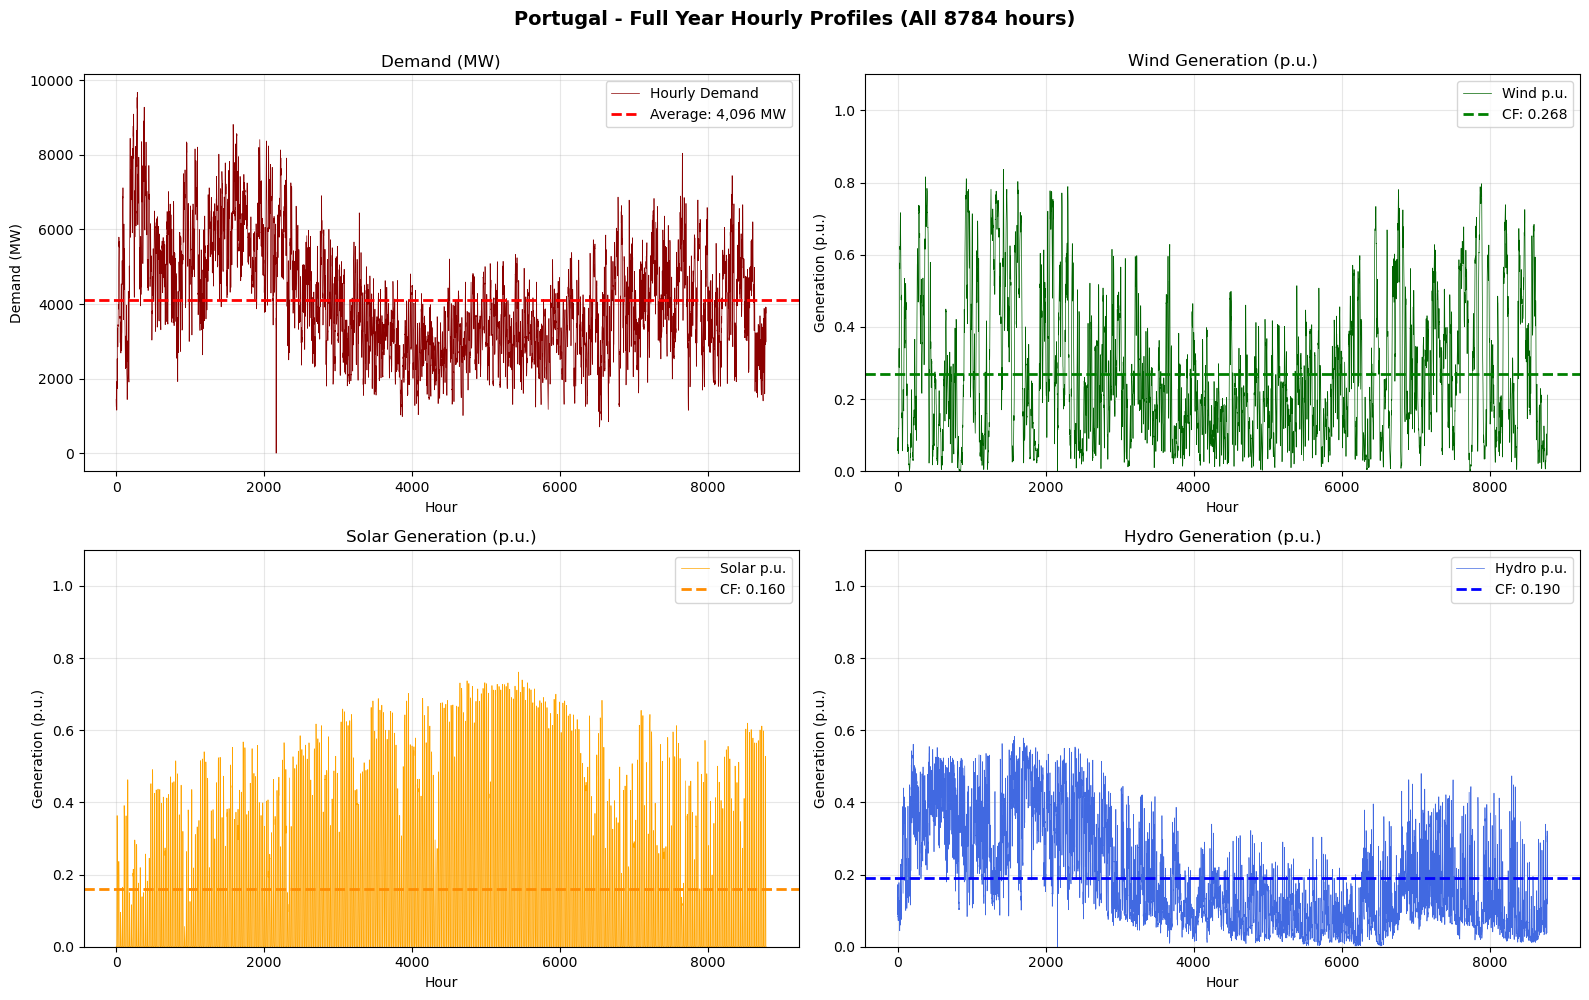


✓ Portugal full-year plots completed

Multi-country analysis complete!

AGGREGATED MULTI-COUNTRY DATA SUMMARY (FULL YEAR)

✓ all_countries_hourly_demand - Dictionary containing hourly demand for each country:
  Spain: 8808 hourly values (MW)
  France: 8784 hourly values (MW)
  Italy: 8784 hourly values (MW)
  Portugal: 8784 hourly values (MW)

✓ all_countries_pu_renewables - Dictionary containing p.u. renewables for each country:
  Spain:
    Wind: 8808 hourly values (p.u.)
    Solar: 8808 hourly values (p.u.)
    Hydro: 8808 hourly values (p.u.)
  France:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)
  Italy:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)
  Portugal:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)

Total hours per country: 8808
Equivalent to: 367.0 days (100.5% of full year)

Varia

In [12]:
# --- Plot p.u. generation for all countries (FULL YEAR) ---
import matplotlib.pyplot as plt
print("\n" + "="*70)
print("MULTI-COUNTRY P.U. GENERATION ANALYSIS - FULL YEAR")
print("="*70 + "\n")

# Initialize aggregated variables
all_countries_hourly_demand = {}
all_countries_pu_renewables = {}

# ===== SPAIN (already in p.u.) =====
print(f"\n{'='*70}")
print("Processing: Spain (p.u. data already available)")
print(f"{'='*70}")
print(f"\nData range: {wind_pu.index[0]} to {wind_pu.index[-1]}")
print(f"Total hours: {len(wind_pu)} hours\n")

# Store Spain's already-calculated p.u. series
spain_wind_pu = wind_pu.values if hasattr(wind_pu, 'values') else wind_pu
spain_solar_pu = solar_pu.values if hasattr(solar_pu, 'values') else solar_pu
spain_hydro_pu = hydro_pu.values if hasattr(hydro_pu, 'values') else hydro_pu
spain_demand = yearly_demand.values if hasattr(yearly_demand, 'values') else yearly_demand

# Calculate capacity factors for Spain
spain_wind_cf = np.mean(spain_wind_pu)
spain_solar_cf = np.mean(spain_solar_pu)
spain_hydro_cf = np.mean(spain_hydro_pu)
spain_avg_demand = np.mean(spain_demand)
spain_peak_demand = np.max(spain_demand)
spain_min_demand = np.min(spain_demand)

print(f"Demand Statistics:")
print(f"  Average: {spain_avg_demand:,.0f} MW")
print(f"  Peak: {spain_peak_demand:,.0f} MW")
print(f"  Minimum: {spain_min_demand:,.0f} MW")
print(f"\nRenewable Capacity Factors (mean p.u.):")
print(f"  Wind: {spain_wind_cf:.3f} ({spain_wind_cf*100:.1f}%)")
print(f"  Solar: {spain_solar_cf:.3f} ({spain_solar_cf*100:.1f}%)")
print(f"  Hydro: {spain_hydro_cf:.3f} ({spain_hydro_cf*100:.1f}%)")

# Store Spain data
all_countries_hourly_demand['Spain'] = spain_demand
all_countries_pu_renewables['Spain'] = {
    'Wind': spain_wind_pu,
    'Solar': spain_solar_pu,
    'Hydro': spain_hydro_pu
}

# Plot Spain
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Spain - Full Year Hourly Profiles (All {len(spain_wind_pu)} hours)', 
             fontsize=14, fontweight='bold', y=0.995)

ax = axes[0, 0]
ax.plot(range(len(spain_demand)), spain_demand, color='darkred', linewidth=0.5, label='Hourly Demand')
ax.axhline(spain_avg_demand, color='red', linestyle='--', linewidth=2, label=f'Average: {spain_avg_demand:,.0f} MW')
ax.set_title('Demand (MW)')
ax.set_ylabel('Demand (MW)')
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.plot(range(len(spain_wind_pu)), spain_wind_pu, color='darkgreen', linewidth=0.5, label='Wind p.u.')
ax.axhline(spain_wind_cf, color='green', linestyle='--', linewidth=2, label=f'CF: {spain_wind_cf:.3f}')
ax.set_title('Wind Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
ax.plot(range(len(spain_solar_pu)), spain_solar_pu, color='orange', linewidth=0.5, label='Solar p.u.')
ax.axhline(spain_solar_cf, color='darkorange', linestyle='--', linewidth=2, label=f'CF: {spain_solar_cf:.3f}')
ax.set_title('Solar Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(range(len(spain_hydro_pu)), spain_hydro_pu, color='royalblue', linewidth=0.5, label='Hydro p.u.')
ax.axhline(spain_hydro_cf, color='blue', linestyle='--', linewidth=2, label=f'CF: {spain_hydro_cf:.3f}')
ax.set_title('Hydro Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
print(f"\n✓ Spain full-year plots completed\n")

# ===== OTHER COUNTRIES (calculate p.u. from installed capacity) =====
# Define installed capacities for other countries (GW converted to MW)
wind_cap_country = {
    "France": 24500,
    "Italy": 13600,
    "Portugal": 6000
}

solar_cap_country = {
    "France": 20000,
    "Italy": 37500,
    "Portugal": 3500
}

hydro_cap_country = {
    "France": 25500,
    "Italy": 22089,
    "Portugal": 7200
}

print("Installed capacities for other countries (MW):")
for country in wind_cap_country.keys():
    print(f"  {country}: Wind={wind_cap_country[country]:,}, Solar={solar_cap_country[country]:,}, Hydro={hydro_cap_country[country]:,}")
print()

# Loop through other countries
for country_name, gen_by_tech_country in gen_by_tech_countries.items():
    print(f"\n{'='*70}")
    print(f"Processing: {country_name}")
    print(f"{'='*70}")
    
    wind_cap = wind_cap_country.get(country_name, 1000.0)
    solar_cap = solar_cap_country.get(country_name, 1000.0)
    hydro_cap = hydro_cap_country.get(country_name, 1000.0)
    
    print(f"\nInstalled capacity (p.u. basis):")
    print(f"  Wind: {wind_cap:,.0f} MW")
    print(f"  Solar: {solar_cap:,.0f} MW")
    print(f"  Hydro: {hydro_cap:,.0f} MW")
    print(f"\nData range: {gen_by_tech_country.index[0]} to {gen_by_tech_country.index[-1]}")
    print(f"Total hours: {len(gen_by_tech_country)} hours\n")
    
    # Calculate p.u. for this country
    demand_arr = gen_by_tech_country['demand'].values
    wind_pu_arr = gen_by_tech_country['Wind'].values / wind_cap if wind_cap > 0 else np.zeros(len(gen_by_tech_country))
    solar_pu_arr = gen_by_tech_country['Solar'].values / solar_cap if solar_cap > 0 else np.zeros(len(gen_by_tech_country))
    hydro_pu_arr = gen_by_tech_country['Hydro'].values / hydro_cap if hydro_cap > 0 else np.zeros(len(gen_by_tech_country))
    
    # Calculate statistics
    avg_demand = np.mean(demand_arr)
    peak_demand = np.max(demand_arr)
    min_demand = np.min(demand_arr)
    wind_cf = np.mean(wind_pu_arr)
    solar_cf = np.mean(solar_pu_arr)
    hydro_cf = np.mean(hydro_pu_arr)
    
    print(f"Demand Statistics:")
    print(f"  Average: {avg_demand:,.0f} MW")
    print(f"  Peak: {peak_demand:,.0f} MW")
    print(f"  Minimum: {min_demand:,.0f} MW")
    print(f"\nRenewable Capacity Factors (mean p.u.):")
    print(f"  Wind: {wind_cf:.3f} ({wind_cf*100:.1f}%)")
    print(f"  Solar: {solar_cf:.3f} ({solar_cf*100:.1f}%)")
    print(f"  Hydro: {hydro_cf:.3f} ({hydro_cf*100:.1f}%)")
    
    # Store data
    all_countries_hourly_demand[country_name] = demand_arr
    all_countries_pu_renewables[country_name] = {
        'Wind': wind_pu_arr,
        'Solar': solar_pu_arr,
        'Hydro': hydro_pu_arr
    }
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{country_name} - Full Year Hourly Profiles (All {len(gen_by_tech_country)} hours)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    ax = axes[0, 0]
    ax.plot(range(len(demand_arr)), demand_arr, color='darkred', linewidth=0.5, label='Hourly Demand')
    ax.axhline(avg_demand, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_demand:,.0f} MW')
    ax.set_title('Demand (MW)')
    ax.set_ylabel('Demand (MW)')
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[0, 1]
    ax.plot(range(len(wind_pu_arr)), wind_pu_arr, color='darkgreen', linewidth=0.5, label='Wind p.u.')
    ax.axhline(wind_cf, color='green', linestyle='--', linewidth=2, label=f'CF: {wind_cf:.3f}')
    ax.set_title('Wind Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[1, 0]
    ax.plot(range(len(solar_pu_arr)), solar_pu_arr, color='orange', linewidth=0.5, label='Solar p.u.')
    ax.axhline(solar_cf, color='darkorange', linestyle='--', linewidth=2, label=f'CF: {solar_cf:.3f}')
    ax.set_title('Solar Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[1, 1]
    ax.plot(range(len(hydro_pu_arr)), hydro_pu_arr, color='royalblue', linewidth=0.5, label='Hydro p.u.')
    ax.axhline(hydro_cf, color='blue', linestyle='--', linewidth=2, label=f'CF: {hydro_cf:.3f}')
    ax.set_title('Hydro Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    print(f"\n✓ {country_name} full-year plots completed\n")

print("="*70)
print("Multi-country analysis complete!")
print("="*70)

# Create aggregated variables summary
print("\n" + "="*70)
print("AGGREGATED MULTI-COUNTRY DATA SUMMARY (FULL YEAR)")
print("="*70 + "\n")

print("✓ all_countries_hourly_demand - Dictionary containing hourly demand for each country:")
for country in all_countries_hourly_demand:
    print(f"  {country}: {len(all_countries_hourly_demand[country])} hourly values (MW)")

print("\n✓ all_countries_pu_renewables - Dictionary containing p.u. renewables for each country:")
for country in all_countries_pu_renewables:
    print(f"  {country}:")
    for tech in ['Wind', 'Solar', 'Hydro']:
        n_hours = len(all_countries_pu_renewables[country][tech])
        print(f"    {tech}: {n_hours} hourly values (p.u.)")

total_hours_per_country = len(list(all_countries_hourly_demand.values())[0]) if all_countries_hourly_demand else 0
print(f"\nTotal hours per country: {total_hours_per_country}")
print(f"Equivalent to: {total_hours_per_country/24:.1f} days ({total_hours_per_country/8760*100:.1f}% of full year)")

print("\n" + "="*70)
print("Variables are ready for further analysis!")
print("="*70)

In [13]:
# =====================
# 1. Prepare multi-country data from existing structures
# =====================

print("="*70)
print("1. PREPARING MULTI-COUNTRY OPTIMIZATION DATA")
print("="*70)

# Convert available data structures to optimization format
demands_multi = {
    'ES': all_countries_hourly_demand['Spain'] if 'Spain' in all_countries_hourly_demand else np.array([]),
    'FR': all_countries_hourly_demand['France'] if 'France' in all_countries_hourly_demand else np.array([]),
    'IT': all_countries_hourly_demand['Italy'] if 'Italy' in all_countries_hourly_demand else np.array([]),
    'PT': all_countries_hourly_demand['Portugal'] if 'Portugal' in all_countries_hourly_demand else np.array([]),
}

renewable_profiles_multi = {
    'ES': all_countries_pu_renewables['Spain'] if 'Spain' in all_countries_pu_renewables else {},
    'FR': all_countries_pu_renewables['France'] if 'France' in all_countries_pu_renewables else {},
    'IT': all_countries_pu_renewables['Italy'] if 'Italy' in all_countries_pu_renewables else {},
    'PT': all_countries_pu_renewables['Portugal'] if 'Portugal' in all_countries_pu_renewables else {},
}

print(f"\n✓ Multi-country demand data prepared:")
for country_code, demand_arr in demands_multi.items():
    if len(demand_arr) > 0:
        print(f"  {country_code}: {len(demand_arr):,} hours, avg={np.mean(demand_arr):.0f} MW")
    else:
        print(f"  {country_code}: NO DATA")

print(f"\n✓ Renewable profiles prepared:")
for country_code, profiles in renewable_profiles_multi.items():
    if profiles:
        print(f"  {country_code}: {len(profiles)} renewable technologies")
        for tech, data in profiles.items():
            if isinstance(data, np.ndarray):
                print(f"    - {tech}: {len(data):,} hourly values")
    else:
        print(f"  {country_code}: NO DATA")


1. PREPARING MULTI-COUNTRY OPTIMIZATION DATA

✓ Multi-country demand data prepared:
  ES: 8,808 hours, avg=28246 MW
  FR: 8,784 hours, avg=58105 MW
  IT: 8,784 hours, avg=21994 MW
  PT: 8,784 hours, avg=4096 MW

✓ Renewable profiles prepared:
  ES: 3 renewable technologies
    - Wind: 8,808 hourly values
    - Solar: 8,808 hourly values
    - Hydro: 8,808 hourly values
  FR: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values
  IT: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values
  PT: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values


# Multi-Country Capacity Expansion Optimization Model 

## Mathematical Formulation

### Sets and Indices
- **C** = Set of countries: {ES, FR, IT, PT}
- **T** = Set of generation technologies: {Wind, Solar, Hydro, CCGT, Coal, Nuclear}
- **S** = Set of storage technologies: {Battery, Hydrogen} — one of each per country
- **L** = Set of transmission interconnections
- **h** ∈ [1, H] = Hourly time steps (H = 8760 for full annual optimization)

### Decision Variables

**Capacity (OPTIMIZED):**
- $Cap_{c,t}$ = Installed capacity of technology t in country c [MW] (**DECISION VARIABLE**)
  - **Bounds:** $Cap_{c,t}^{min} \leq Cap_{c,t} \leq Cap_{c,t}^{max}$ for all c, t

**Hourly Generation:**
- $G_{c,t,h}$ = Hourly generation from technology t in country c at hour h [MWh]
  - **Bounds:** $0 \leq G_{c,t,h} \leq CF_{c,t,h} \cdot Cap_{c,t}$ for renewables (Wind, Solar, Hydro)
  - **Bounds:** $0 \leq G_{c,t,h} \leq Cap_{c,t}$ for non-renewables (CCGT, Coal, Nuclear)

**Power Flows:**
- $F_{l,h}$ = Power flow on interconnection line l at hour h [MW]
  - **Bounds:** $-NTC_l \leq F_{l,h} \leq NTC_l$ (bidirectional)

**Storage Capacity (OPTIMIZED):**
- $P^{bat}_{c}$ = Battery power capacity in country c [MW] (**DECISION VARIABLE**)
- $E^{bat}_{c}$ = Battery energy capacity in country c [MWh] (**DECISION VARIABLE**)
- $P^{H2}_{c}$ = Hydrogen power capacity in country c [MW] (**DECISION VARIABLE**)
- $E^{H2}_{c}$ = Hydrogen energy capacity in country c [MWh] (**DECISION VARIABLE**)
  - **Bounds (Power):** $0 \leq P^{bat}_{c} \leq 100,000$ MW; $0 \leq P^{H2}_{c} \leq 100,000$ MW
  - **Bounds (Energy):** $0 \leq E^{bat}_{c} \leq 100,000 \times 4$ MWh; $0 \leq E^{H2}_{c} \leq 100,000 \times 168$ MWh

**Storage Dispatch (Hourly):**
- $Ch^{bat}_{c,h}$ = Battery charging power in country c at hour h [MW] (positive = charging)
- $Disch^{bat}_{c,h}$ = Battery discharging power in country c at hour h [MW] (positive = discharging)
- $E^{bat}_{c,h}$ = Battery state of charge (energy) in country c at hour h [MWh]
- $Ch^{H2}_{c,h}$ = Hydrogen charging (electrolyzer) power in country c at hour h [MW]
- $Disch^{H2}_{c,h}$ = Hydrogen discharging (fuel cell) power in country c at hour h [MW]
- $E^{H2}_{c,h}$ = Hydrogen state of energy in country c at hour h [MWh]
  - **Bounds:** All ≥ 0; discharge and charge cannot occur simultaneously per storage unit

### Parameters

| Symbol | Description | Units | Source |
|--------|-------------|-------|--------|
| $D_{c,h}$ | Hourly electricity demand in country c at hour h | MWh | Full-year data by country |
| $c^{cap}_t$ | Capital cost of technology t (annualized, same for all countries) | €/MW/year | Tech cost database |
| $c^V_t$ | Variable/fuel cost of technology t (same for all countries) | €/MWh | Tech cost database |
| $CF_{c,t,h}$ | Actual capacity factor for technology t in country c at hour h | p.u. (0-1) | Generation data ÷ installed capacity |
| $Cap_{c,t}^{min}$ | Minimum capacity bound for technology t in country c | MW | 0 MW (no minimum) |
| $Cap_{c,t}^{max}$ | Maximum capacity bound for technology t in country c | MW | 30,000–70,000 MW (tech-dependent) |
| $NTC_l$ | Net Transfer Capacity of interconnection line l | MW | TSO data |

### Capacity Factor Data

Capacity factors are calculated from historical generation data and baseline installed capacities:
- **Spain (ES):** From `gen_by_tech` (2024 full-year generation data)
- **France (FR):** From French generation data (Wind: 24.5 GW, Solar: 20 GW, Hydro: 25.5 GW)
- **Italy (IT):** From Italian generation data (Wind: 13.6 GW, Solar: 43.5 GW, Hydro: 22.1 GW)
- **Portugal (PT):** From Portuguese generation data (Wind: 6 GW, Solar: 3.5 GW, Hydro: 7.2 GW)

**Transmission Network Structure:**
```
          France (FR)------------------
            |                         |
            |                         |
       4500 MW (NTC)             3500 MW (NTC)
            |                         |
            |                         |
          Spain---2000 MW (NTC)---Italy (IT)
          (ES)
            |
            |
          4500 MW (NTC)
            |
          Portugal
          (PT)
```

### Objective Function

Minimize total annual cost (capital + variable):

$$\min Z = \sum_{c \in C} \sum_{t \in T} \left[ c^{cap}_t \cdot Cap_{c,t} + \sum_{h \in H} c^V_t \cdot G_{c,t,h} \right] + \sum_{c \in C} \left[ c^{cap,bat} \cdot P^{bat}_{c} + c^{cap,H2} \cdot P^{H2}_{c} \right]$$

**Decomposition:**
- **Generation fixed cost:** $c^{cap}_t \cdot Cap_{c,t}$ = Annualized generation capacity cost (€/year)
- **Generation variable cost:** $c^V_t \cdot G_{c,t,h}$ = Hourly generation fuel/operational cost (€/MWh)
- **Battery capital cost:** $c^{cap,bat} \cdot P^{bat}_{c}$ = Annualized battery power capacity cost per country (€/MW/year)
- **Hydrogen capital cost:** $c^{cap,H2} \cdot P^{H2}_{c}$ = Annualized hydrogen power capacity cost per country (€/MW/year)

### Constraints

**1. Capacity Bounds:**

For each technology t in country c:
$$Cap_{c,t}^{min} \leq Cap_{c,t} \leq Cap_{c,t}^{max} \quad \forall c, t$$

**2. Energy Balance Constraint (Kirchhoff's Voltage Law with Storage):**

For each country c and hour h:
$$\sum_{t \in T} G_{c,t,h} + Disch^{bat}_{c,h} + Disch^{H2}_{c,h} + \sum_{l \text{ incoming to } c} F_{l,h} = D_{c,h} + Ch^{bat}_{c,h} + Ch^{H2}_{c,h} + \sum_{l \text{ outgoing from } c} F_{l,h}$$

*Interpretation:* Total generation + storage discharge + incoming imports = Demand + storage charging + outgoing exports

**3. Renewable Generation Constraint (Actual Capacity Factor Limit):**

For renewable technologies (Wind, Solar, Hydro) in country c at hour h:
$$G_{c,t,h} \leq CF_{c,t,h} \cdot Cap_{c,t} \quad \forall c, t \in \{Wind, Solar, Hydro\}, h$$

**4. Non-Renewable Generation Constraint:**

For non-renewable technologies (CCGT, Coal, Nuclear) in country c at hour h:
$$G_{c,t,h} \leq Cap_{c,t} \quad \forall c, t \in \{CCGT, Coal, Nuclear\}, h$$

**5. Transmission Line Flow Constraints (Bidirectional NTC Limits):**

For each interconnection line l at hour h:
$$-NTC_l \leq F_{l,h} \leq NTC_l$$

**6. Battery Storage Constraints (per country c):**

Battery charging/discharging power limits:
$$0 \leq Ch^{bat}_{c,h} \leq P^{bat}_{c} \quad \forall c, h$$
$$0 \leq Disch^{bat}_{c,h} \leq P^{bat}_{c} \quad \forall c, h$$

Battery state of charge (energy balance, with round-trip efficiency):
$$E^{bat}_{c,h} = E^{bat}_{c,h-1} \cdot (1 - loss^{bat}) + Ch^{bat}_{c,h} \cdot \eta^{bat}_{ch} - \frac{Disch^{bat}_{c,h}}{\eta^{bat}_{disch}} \quad \forall c, h$$

where:
- $\eta^{bat}_{ch} = 0.95$ = Charging efficiency
- $\eta^{bat}_{disch} = 0.9$ = Discharging efficiency
- $loss^{bat} = 0.0$ = Hourly standing loss

Battery energy capacity constraint:
$$E^{bat}_{c,h} \leq E^{bat}_{c} = P^{bat}_{c} \times 4 \text{ hours} \quad \forall c, h$$

Battery maximum duration constraint:
$$E^{bat}_{c} \leq P^{bat}_{c} \times 4 \quad \forall c$$

**7. Hydrogen Storage Constraints (per country c):**

Hydrogen charging (electrolyzer) and discharging (fuel cell) limits:
$$0 \leq Ch^{H2}_{c,h} \leq P^{H2}_{c} \quad \forall c, h$$
$$0 \leq Disch^{H2}_{c,h} \leq P^{H2}_{c} \quad \forall c, h$$

Hydrogen state of charge (energy balance, with round-trip efficiency):
$$E^{H2}_{c,h} = E^{H2}_{c,h-1} \cdot (1 - loss^{H2}) + Ch^{H2}_{c,h} \cdot \eta^{H2}_{ch} - \frac{Disch^{H2}_{c,h}}{\eta^{H2}_{disch}} \quad \forall c, h$$

where:
- $\eta^{H2}_{ch} = 0.65$ = Electrolyzer efficiency
- $\eta^{H2}_{disch} = 0.65$ = Fuel cell efficiency
- $loss^{H2} = 0.0$ = Hourly standing loss

Hydrogen energy capacity constraint:
$$E^{H2}_{c,h} \leq E^{H2}_{c} = P^{H2}_{c} \times 168 \text{ hours} \quad \forall c, h$$

Hydrogen maximum duration (weekly storage):
$$E^{H2}_{c} \leq P^{H2}_{c} \times 168 \quad \forall c$$

**8. Non-Negativity Constraints:**

$$Cap_{c,t} \geq 0, \quad G_{c,t,h} \geq 0, \quad P^{bat}_{c} \geq 0, \quad P^{H2}_{c} \geq 0 \quad \forall c, t, h$$

### Transmission Network Details

**Interconnections with NTC Capacity (MW):**
| Line | From | To | Capacity | Direction |
|------|------|----|-----------| --------  |
| 1 | Spain (ES) | France (FR) | 3500 | Bidirectional |
| 2 | France (FR) | Italy (IT) | 4500 | Bidirectional |
| 3 | Spain (ES) | Italy (IT) | 2000 | Bidirectional |
| 4 | Spain (ES) | Portugal (PT) | 4500 | Bidirectional |

### Optimization Problem Summary

**Type:** Mixed-Integer Linear Programming (MILP) - Capacity Expansion with Storage
**Solver:** Gurobi (academic license valid until 2026-05-10)
**Objective:** Total annual system cost minimization (generation + storage capital costs)
**Variables:** 
- Generation capacity: $|C| \times |T| = 4 \times 6 = 24$ variables
- Storage capacity (power & energy): $|C| \times 2 \times 2 = 16$ variables (battery + hydrogen per country)
- Generation dispatch: $|C| \times |T| \times H = 4 \times 6 \times 8760 ≈ 210,000$ variables
- Storage dispatch: $|C| \times 2 \times H \times 2 = 4 \times 2 \times 8760 \times 2 ≈ 140,000$ variables (charge/discharge per storage)
- Power flows: $|L| \times H = 4 \times 8760 ≈ 35,000$ variables
- **Total: ≈ 390,000 variables**

**Constraints:** 
- Energy balance: $|C| \times H ≈ 35,000$ constraints
- Transmission: $|L| \times H ≈ 35,000$ constraints
- Storage dynamics: $|C| \times 2 \times H \times 2 ≈ 140,000$ constraints
- **Total: ≈ 210,000 constraints**

### Key Assumptions (Updated with Storage)

1. **Perfect Foresight:** All demand and renewable generation known in advance (no uncertainty)
2. **Full-Year Optimization:** Entire 8760-hour year optimized jointly (not representative weeks)
3. **Actual Capacity Factors:** Based on real historical generation data by country (not synthetic)
4. **Same Technology Costs:** All countries use identical capital and variable costs for same technology
5. **Continuous Variables:** Capacities and generation are continuous (no discrete size increments)
6. **No Ramp Constraints:** Generators can change output instantly
7. **No Transmission Losses:** Power flows have no distance-dependent losses
8. **No Unit Commitment:** No start-up costs or minimum stable generation requirements
9. **No Reserve Constraints:** No spinning or standing reserve requirements
10. **Independent Storage per Country:** Each country has its own battery and hydrogen storage units (no cross-border storage flows)
11. **Battery & Hydrogen Independent:** Battery and hydrogen operate independently (can both charge/discharge in same hour)
12. **Simultaneous Optimization:** All countries' capacities and storage optimized together (multi-country problem)

In [14]:
# =====================
# SOLVE MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE OPTIMIZATION
# =====================

import shutil
from pathlib import Path

print("\n" + "="*70)
print("3. SOLVING MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE")
print("   (Optimizing capacities + Battery + Hydrogen for all countries)")
print("="*70)

# Reload module to get updated function with storage
module_dir = Path.cwd() / "python_codes"
pycache_dir = module_dir / "__pycache__"
if pycache_dir.exists():
    shutil.rmtree(pycache_dir)

mods_to_remove = [mod for mod in sys.modules if 'abstract_multi_country' in mod]
for mod in mods_to_remove:
    del sys.modules[mod]

from python_codes.abstract_multi_country import optimize_multi_country_capacity_expansion_with_storage


print(f"\nCommon technology cost structure (all countries):")

# Aggregate costs by technology category
def aggregate_costs(tech_name, cost_df, tech_mapping, avg_gas_price=35.0):
    """Aggregate costs for a technology category."""
    matching_rows = cost_df[cost_df['Technology'].isin(tech_mapping.get(tech_name, []))]
    if len(matching_rows) == 0:
        return None
    
    # Use the first matching row (or could do weighting)
    row = matching_rows.iloc[0]
    
    # Annualized cost: €/kWel/year -> €/MW/year
    capcost_mw = row['Annualized Cost (€/kW/a)'] * 1000
    
    # Fixed cost (annual): CAPEX * FOM%
    fixed_cost = capcost_mw * (row['FOM (%/a)'] / 100.0)
    
    # Fuel cost
    fuel_cost = row['Fuel Cost (€/MWh)']
    
    return {
        'variable_cost': fuel_cost,
        'fixed_cost': fixed_cost,
        'min_cap': 0,
        'max_cap': 100000,  # Large max capacity
    }

# === Load technology costs from CSV ===
cost_df = pd.read_csv('./Data/Techs_cost_FOM_&_Fuel_cost.csv')
print("Available technologies in cost file:")
display(cost_df[['Technology', 'Category', 'Overnight Cost', 'FOM (%/a)', 'Fuel Cost (€/MWh)']])

# Map technologies to our naming convention
tech_mapping = {
    'Wind': ['Wind onshore', 'Wind offshore'],
    'Solar': ['Solar PV rooftop', 'Solar PV utility'],
    'Hydro': ['Hydro reservoir', 'Run-of-river', 'Pumped hydro storage'],
    'CCGT': ['Open cycle gas turbine (OCGT)'],
    'CHP': ['Combined heat and power (CHP) central'],
    'Coal': ['Coal'],
    'Nuclear': ['Nuclear'],
}

# Build tech parameters
tech_params_opt = {}
for tech in ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']:
    params = aggregate_costs(tech, cost_df, tech_mapping)
    if params:
        tech_params_opt[tech] = params
        print(f"{tech}: Fixed cost = €{params['fixed_cost']:.1f}/MW/year, Fuel cost = €{params['variable_cost']:.2f}/MWh")

# === Apply hydro capacity constraint ===
# Limit hydro to the baseline capacity used in p.u. calculations
tech_params_opt['Hydro']['max_cap'] = hydro_cap
print(f"\nHydro capacity constraint: max = {hydro_cap:,.0f} MW (from baseline data)")
tech_params_multi = {
    'Wind': {
        'variable_cost': tech_params_opt['Wind']['variable_cost'],
        'fixed_cost': tech_params_opt['Wind']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Solar': {
        'variable_cost': tech_params_opt['Solar']['variable_cost'],
        'fixed_cost': tech_params_opt['Solar']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Hydro': {
        'variable_cost': tech_params_opt['Hydro']['variable_cost'],
        'fixed_cost': tech_params_opt['Hydro']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 30000,  # Default for ES, FR, IT
        'max_cap_by_country': {
            'ES': 17000,   # Spain: 17 GW
            'FR': 26000,   # France: 26 GW
            'IT': 22000,   # Italy: 22 GW
            'PT': 8500,    # Portugal: 8.5 GW (CAP)
        }
    },
    'CCGT': {
        'variable_cost': tech_params_opt['CCGT']['variable_cost'],
        'fixed_cost': tech_params_opt['CCGT']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Coal': {
        'variable_cost': tech_params_opt['Coal']['variable_cost'],
        'fixed_cost': tech_params_opt['Coal']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 30000,
    },
    'Nuclear': {
        'variable_cost': tech_params_opt['Nuclear']['variable_cost'],
        'fixed_cost': tech_params_opt['Nuclear']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 70000,
    },
}

for tech, params in tech_params_multi.items():
    print(f"  {tech}: Fixed=€{params['fixed_cost']:.1f}/MW/yr, Variable=€{params['variable_cost']:.2f}/MWh")

# =====================
# 4. Define transmission interconnections (NTC from TSO data)
# =====================

interconnections = [
    ('ES', 'FR', 3500),  # Spain-France
    ('FR', 'IT', 4500),  # France-Italy
    ('ES', 'IT', 2000),  # Spain-Italy (direct)
    ('ES', 'PT', 4500),  # Spain-Portugal
]

print(f"\nTransmission network (NTC - Net Transfer Capacity):")
for from_c, to_c, ntc in interconnections:
    print(f"  {from_c} → {to_c}: {ntc:,} MW (bidirectional)")

# =====================
# 5. Prepare input data structure for optimization
# =====================

multi_country_data = {
    'demands': demands_multi,
    'tech_params': tech_params_multi,
    'renewable_profiles': renewable_profiles_multi,
    'interconnections': interconnections,
}

print(f"\n✓ Multi-country capacity expansion data prepared successfully!")
print(f"  - Countries: {list(demands_multi.keys())}")
print(f"  - Time periods: {len(demands_multi['ES'])} hours")
print(f"  - Technologies: {list(tech_params_multi.keys())}")


# Load storage costs from CSV
cost_df_storage = pd.read_csv('./Data/Techs_&_storage_cost_FOM_&_Fuel_cost.csv')

# Extract battery costs from CSV
battery_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Battery system'].iloc[0]
battery_overnight_cost = battery_tech_row['Overnight Cost']  # €/kWel
battery_fom = battery_tech_row['FOM (%/a)'] / 100.0
battery_efficiency = battery_tech_row['Efficiency']
battery_fixed_cost = battery_overnight_cost * 1000 * battery_fom  # €/MW/year

# Extract hydrogen costs from CSV
hydrogen_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Hydrogen system'].iloc[0]
hydrogen_overnight_cost = hydrogen_tech_row['Annualized Cost (€/kW/a)']  # €/kWel/year
hydrogen_fom = hydrogen_tech_row['FOM (%/a)'] / 100.0
hydrogen_efficiency = hydrogen_tech_row['Efficiency']
hydrogen_fixed_cost = hydrogen_overnight_cost * 1000 * hydrogen_fom  # €/MW/year

print(f"\n Storage technology parameters from CSV:")
print(f"\n Battery system:")
print(f"  Overnight cost: €{battery_overnight_cost:.0f}/kWel")
print(f"  FOM: {battery_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{battery_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {battery_efficiency*100:.0f}%")
print(f"  Charging efficiency: {battery_efficiency**0.5:.3f}")
print(f"  Discharging efficiency: {battery_efficiency**0.5:.3f}")

print(f"\n Hydrogen system:")
print(f"  Overnight cost: €{hydrogen_overnight_cost:.0f}/kWel")
print(f"  FOM: {hydrogen_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{hydrogen_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {hydrogen_efficiency*100:.0f}%")
print(f"  Electrolyzer efficiency: {hydrogen_efficiency**0.5:.3f}")
print(f"  Fuel cell efficiency: {hydrogen_efficiency**0.5:.3f}\n")

# Run joint optimization with both battery and hydrogen storage across all countries
try:
    result_multi_storage = optimize_multi_country_capacity_expansion_with_storage(
        data=multi_country_data,
        # Battery parameters (per country)
        battery_max_hours=4.0,
        battery_charging_efficiency=battery_efficiency**0.5,
        battery_discharging_efficiency=battery_efficiency**0.5,
        battery_standing_loss=0.0,
        battery_fixed_cost=battery_fixed_cost,
        battery_variable_cost=0.0,
        battery_max_capacity_limit=50000.0,
        # Hydrogen parameters (per country)
        hydrogen_max_hours=168.0,  # 1 week storage
        hydrogen_charging_efficiency=hydrogen_efficiency**0.5,
        hydrogen_discharging_efficiency=hydrogen_efficiency**0.5,
        hydrogen_standing_loss=0.0,
        hydrogen_fixed_cost=hydrogen_fixed_cost,
        hydrogen_variable_cost=0.0,
        hydrogen_max_capacity_limit=50000.0,
        solver_name="gurobi",
    )
    
    print(f"\n✓ Multi-country optimization WITH STORAGE completed successfully!")
    print(f"\nOptimization Status: {result_multi_storage.status}")
    print(f"Total Annual Cost: €{result_multi_storage.objective_value:,.0f}")
    #print(f"Cost difference vs. no-storage: €{result_multi_storage.objective_value - result_multi.objective_value:,.0f}")
    
except Exception as e:
    print(f"\n✗ Optimization error: {type(e).__name__}")
    print(f"  {str(e)}")
    raise

print("\n" + "="*70)


3. SOLVING MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE
   (Optimizing capacities + Battery + Hydrogen for all countries)



Common technology cost structure (all countries):
Available technologies in cost file:


,Technology,Category,Overnight Cost,FOM (%/a),Fuel Cost (€/MWh)
0,Wind onshore,wind,1182,3.0,0.00
1,Wind offshore,wind,2506,3.0,0.00
2,Solar PV rooftop,solar,725,2.0,0.00
3,Solar PV utility,solar,425,3.0,0.00
4,Pumped hydro storage,hydro,2000,1.0,0.00
5,Hydro reservoir,hydro,2000,1.0,0.00
6,Run-of-river,hydro,3000,2.0,0.00
7,Combined heat and power (CHP) central,chp,600,3.0,87.50
8,Open cycle gas turbine (OCGT),fossil,400,4.0,30.00
9,Coal,coal,3000,3.0,61.52


Wind: Fixed cost = €2513.4/MW/year, Fuel cost = €0.00/MWh
Solar: Fixed cost = €1028.8/MW/year, Fuel cost = €0.00/MWh
Hydro: Fixed cost = €1020.4/MW/year, Fuel cost = €0.00/MWh
CCGT: Fixed cost = €1040.8/MW/year, Fuel cost = €30.00/MWh
Coal: Fixed cost = €5238.3/MW/year, Fuel cost = €61.52/MWh
Nuclear: Fixed cost = €7926.0/MW/year, Fuel cost = €8.50/MWh

Hydro capacity constraint: max = 7,200 MW (from baseline data)
  Wind: Fixed=€2513.4/MW/yr, Variable=€0.00/MWh
  Solar: Fixed=€1028.8/MW/yr, Variable=€0.00/MWh
  Hydro: Fixed=€1020.4/MW/yr, Variable=€0.00/MWh
  CCGT: Fixed=€1040.8/MW/yr, Variable=€30.00/MWh
  Coal: Fixed=€5238.3/MW/yr, Variable=€61.52/MWh
  Nuclear: Fixed=€7926.0/MW/yr, Variable=€8.50/MWh

Transmission network (NTC - Net Transfer Capacity):
  ES → FR: 3,500 MW (bidirectional)
  FR → IT: 4,500 MW (bidirectional)
  ES → IT: 2,000 MW (bidirectional)
  ES → PT: 4,500 MW (bidirectional)

✓ Multi-country capacity expansion data prepared successfully!
  - Countries: ['ES', 'FR

d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment\python_codes\abstract_multi_country.py:601: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(
Index(['ES', 'FR', 'IT', 'PT'], dtype='str', name='name')
Index(['interconnection_ES_FR', 'interconnection_FR_IT', 'interconnection_ES_IT', 'interconnection_ES_PT'], dtype='str', name='name')
Index(['interconnection_ES_FR', 'interconnection_FR_IT', 'interconnection_ES_IT', 'interconnection_ES_PT'], dtype='str', name='name')


...

Solved in 131168 iterations and 199.75 seconds (50.35 work units)


INFO:gurobipy:Solved in 131168 iterations and 199.75 seconds (50.35 work units)


Optimal objective  4.266923899e+09


INFO:gurobipy:Optimal objective  4.266923899e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 456800 primals, 1027792 duals
Objective: 4.27e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


✓ Optimization complete


✓ Multi-country optimization WITH STORAGE completed successfully!

Optimization Status: optimal
Total Annual Cost: €4,266,923,899




4. OPTIMIZED STORAGE CAPACITIES BY TYPE FOR EACH COUNTRY

Optimized Storage Capacities (MW):

Country           Battery (MW)     Hydrogen (MW)     Total (MW)
---------------------------------------------------------------
ES                           0             2,772          2,772
FR                           0                 0              0
IT                           0             5,304          5,304
PT                           0             4,345          4,345
---------------------------------------------------------------
TOTAL                        0            12,421         12,421

4b. OPTIMIZED CAPACITIES BY TECHNOLOGY FOR EACH COUNTRY (WITH STORAGE)

Optimized Capacities (MW):

Technology               ES          FR          IT          PT       TOTAL
---------------------------------------------------------------------------
CCGT                  8,891       6,685       7,596         229      23,400
Coal                      0           0           0           0 


✓ Capacity plot (with storage) saved to './Plots/5_Multi_country_optimized_capacities_WITH_STORAGE.png'


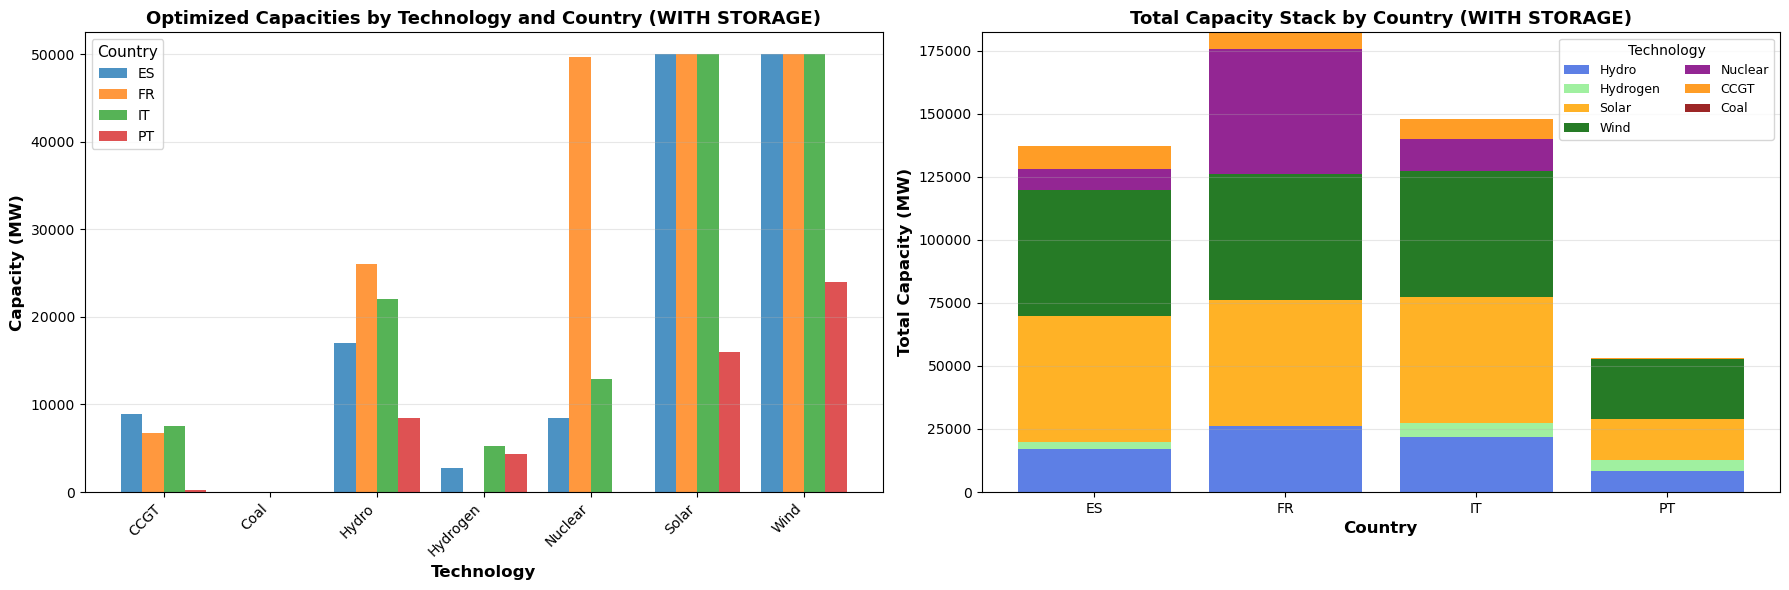

In [15]:
# =====================
# RESULTS: STORAGE CAPACITIES & OPTIMIZED GENERATION WITH STORAGE
# =====================

print("\n" + "="*70)
print("4. OPTIMIZED STORAGE CAPACITIES BY TYPE FOR EACH COUNTRY")
print("="*70)

# Extract storage capacities from PyPSA network
storage_capacities = {}
for country in ['ES', 'FR', 'IT', 'PT']:
    storage_capacities[country] = {'Battery': 0, 'Hydrogen': 0}

# Get all storage units from network
for store_name, store_row in result_multi_storage.network.storage_units.iterrows():
    if 'battery' in store_name.lower():
        for country in ['ES', 'FR', 'IT', 'PT']:
            if country in store_name:
                storage_capacities[country]['Battery'] = store_row.get('p_nom_opt', store_row['p_nom'])
                break
    elif 'hydrogen' in store_name.lower():
        for country in ['ES', 'FR', 'IT', 'PT']:
            if country in store_name:
                storage_capacities[country]['Hydrogen'] = store_row.get('p_nom_opt', store_row['p_nom'])
                break

# Print storage capacities
print("\nOptimized Storage Capacities (MW):\n")
print(f"{'Country':<12}{'Battery (MW)':>18}{'Hydrogen (MW)':>18}{'Total (MW)':>15}")
print("-" * 63)

total_battery = 0
total_hydrogen = 0
for country in ['ES', 'FR', 'IT', 'PT']:
    battery_cap = storage_capacities[country]['Battery']
    hydrogen_cap = storage_capacities[country]['Hydrogen']
    total_cap = battery_cap + hydrogen_cap
    total_battery += battery_cap
    total_hydrogen += hydrogen_cap
    print(f"{country:<12}{battery_cap:>18,.0f}{hydrogen_cap:>18,.0f}{total_cap:>15,.0f}")

print("-" * 63)
print(f"{'TOTAL':<12}{total_battery:>18,.0f}{total_hydrogen:>18,.0f}{total_battery + total_hydrogen:>15,.0f}")

# =====================
# RESULTS: OPTIMIZED CAPACITIES & ANNUAL GENERATION WITH STORAGE
# =====================

print("\n" + "="*70)
print("4b. OPTIMIZED CAPACITIES BY TECHNOLOGY FOR EACH COUNTRY (WITH STORAGE)")
print("="*70)

# Extract capacities from PyPSA network
capacities_by_country_tech = {}
for country in ['ES', 'FR', 'IT', 'PT']:
    capacities_by_country_tech[country] = {}

# Get all generators from network
for gen_name, gen_row in result_multi_storage.network.generators.iterrows():
    if gen_name.startswith('gen_'):
        gen_name_clean = gen_name[4:]  # Remove "gen_" prefix
        parts = gen_name_clean.split('_')
        if len(parts) >= 2:
            country = parts[0]
            tech = '_'.join(parts[1:])
            
            if country in capacities_by_country_tech:
                p_nom_opt = gen_row.get('p_nom_opt', gen_row['p_nom'])
                capacities_by_country_tech[country][tech] = p_nom_opt

# Add storage capacities to the table
for country in ['ES', 'FR', 'IT', 'PT']:
    if storage_capacities[country]['Battery'] > 0:
        capacities_by_country_tech[country]['Battery'] = storage_capacities[country]['Battery']
    if storage_capacities[country]['Hydrogen'] > 0:
        capacities_by_country_tech[country]['Hydrogen'] = storage_capacities[country]['Hydrogen']

# Create a summary table and print
print("\nOptimized Capacities (MW):\n")

# Collect all techs across all countries
all_techs = set()
for country_caps in capacities_by_country_tech.values():
    all_techs.update(country_caps.keys())
all_techs = sorted(list(all_techs))

if all_techs:
    # Print table header
    print(f"{'Technology':<15}", end='')
    for country in ['ES', 'FR', 'IT', 'PT']:
        print(f"{country:>12}", end='')
    print(f"{'TOTAL':>12}")
    print("-" * (15 + 12*4 + 12))

    # Print each technology row
    for tech in all_techs:
        print(f"{tech:<15}", end='')
        total_cap = 0
        for country in ['ES', 'FR', 'IT', 'PT']:
            cap = capacities_by_country_tech[country].get(tech, 0)
            total_cap += cap
            print(f"{cap:>12,.0f}", end='')
        print(f"{total_cap:>12,.0f}")

    # Print totals by country
    print("-" * (15 + 12*4 + 12))
    print(f"{'TOTAL':<15}", end='')
    for country in ['ES', 'FR', 'IT', 'PT']:
        total_cap = sum(capacities_by_country_tech[country].values())
        print(f"{total_cap:>12,.0f}", end='')
    total_all = sum(sum(c.values()) for c in capacities_by_country_tech.values())
    print(f"{total_all:>12,.0f}")
else:
    print("No generators found in network!")

# =====================
# RESULTS: OPTIMIZED GENERATIONS BY COUNTRY WITH STORAGE
# =====================

print("\n" + "="*70)
print("4c. OPTIMIZED ANNUAL GENERATIONS BY TECHNOLOGY FOR EACH COUNTRY (WITH STORAGE)")
print("="*70)

# Extract generations from PyPSA network results
generations_by_country_tech = {}
for country in ['ES', 'FR', 'IT', 'PT']:
    generations_by_country_tech[country] = {}

# Get all generators from network and their generation time series
for gen_name, gen_row in result_multi_storage.network.generators.iterrows():
    if gen_name.startswith('gen_'):
        gen_name_clean = gen_name[4:]
        parts = gen_name_clean.split('_')
        if len(parts) >= 2:
            country = parts[0]
            tech = '_'.join(parts[1:])
            
            if country in generations_by_country_tech:
                if gen_name in result_multi_storage.network.generators_t.p.columns:
                    annual_gen = result_multi_storage.network.generators_t.p[gen_name].sum()
                    generations_by_country_tech[country][tech] = annual_gen
                else:
                    generations_by_country_tech[country][tech] = 0

# Extract storage dispatch data (discharge operations)
for store_name, store_row in result_multi_storage.network.storage_units.iterrows():
    if 'battery' in store_name.lower():
        for country in ['ES', 'FR', 'IT', 'PT']:
            if country in store_name:
                if store_name in result_multi_storage.network.storage_units_t.p_dispatch.columns:
                    annual_dispatch = result_multi_storage.network.storage_units_t.p_dispatch[store_name].sum()
                    generations_by_country_tech[country]['Battery'] = annual_dispatch
                break
    elif 'hydrogen' in store_name.lower():
        for country in ['ES', 'FR', 'IT', 'PT']:
            if country in store_name:
                if store_name in result_multi_storage.network.storage_units_t.p_dispatch.columns:
                    annual_dispatch = result_multi_storage.network.storage_units_t.p_dispatch[store_name].sum()
                    generations_by_country_tech[country]['Hydrogen'] = annual_dispatch
                break

# Create a summary table and print
print("\nOptimized Annual Generations (MWh):\n")

# Collect all techs across all countries
all_gen_techs = set()
for country_gens in generations_by_country_tech.values():
    all_gen_techs.update(country_gens.keys())
all_gen_techs = sorted(list(all_gen_techs))

if all_gen_techs:
    # Print table header
    print(f"{'Technology':<15}", end='')
    for country in ['ES', 'FR', 'IT', 'PT']:
        print(f"{country:>18}", end='')
    print(f"{'TOTAL':>18}")
    print("-" * (15 + 18*4 + 18))

    # Print each technology row
    for tech in all_gen_techs:
        print(f"{tech:<15}", end='')
        total_gen = 0
        for country in ['ES', 'FR', 'IT', 'PT']:
            gen = generations_by_country_tech[country].get(tech, 0)
            total_gen += gen
            # Print in GWh for better readability
            print(f"{gen/1e3:>18,.1f}", end='')
        print(f"{total_gen/1e3:>18,.1f}")

    # Print totals by country
    print("-" * (15 + 18*4 + 18))
    print(f"{'TOTAL':<15}", end='')
    for country in ['ES', 'FR', 'IT', 'PT']:
        total_gen = sum(generations_by_country_tech[country].values())
        print(f"{total_gen/1e3:>18,.1f}", end='')
    total_all = sum(sum(g.values()) for g in generations_by_country_tech.values())
    print(f"{total_all/1e3:>18,.1f}")
    print("\nNote: All values are in GWh (annual totals)")
else:
    print("No generation data found in results!")

# =====================
# PLOT: OPTIMIZED CAPACITIES WITH STORAGE
# =====================

if all_techs:
    print("\n" + "="*70)
    print("5. VISUALIZATION: OPTIMIZED CAPACITIES WITH STORAGE BY TECHNOLOGY & COUNTRY")
    print("="*70)

    # Create a more comprehensive capacity visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot 1: Grouped bar chart - Capacity by technology for each country
    countries_list = ['ES', 'FR', 'IT', 'PT']
    x = np.arange(len(all_techs))
    width = 0.2
    colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, country in enumerate(countries_list):
        capacities = [capacities_by_country_tech[country].get(tech, 0) for tech in all_techs]
        ax1.bar(x + idx*width, capacities, width, label=country, color=colors_bar[idx], alpha=0.8)

    ax1.set_xlabel('Technology', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Capacity (MW)', fontsize=12, fontweight='bold')
    ax1.set_title('Optimized Capacities by Technology and Country (WITH STORAGE)', fontsize=13, fontweight='bold')
    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(all_techs, rotation=45, ha='right')
    ax1.legend(title='Country', fontsize=10, title_fontsize=11)
    ax1.grid(True, alpha=0.3, axis='y')

    # Plot 2: Stacked bar chart - Total capacity by country
    x_pos = np.arange(len(countries_list))
    bottom = np.zeros(len(countries_list))

    # Define a colormap for technologies
    color_map = {
        'Wind': 'darkgreen',
        'Solar': 'orange',
        'Hydro': 'royalblue',
        'Coal': 'darkred',
        'Nuclear': 'purple',
        'CCGT': 'darkorange',
        'Diesel': 'red',
        'CHP': 'saddlebrown',
        'HVDC': 'black',
        'OtherRenew': 'lightgreen',
        'Waste': 'darkgray',
        'Battery': 'cyan',
        'Hydrogen': 'lightgreen'
    }
    
    # Get variable costs for each technology to sort by cost
    tech_costs = {}
    for tech in all_techs:
        # Find generators of this technology and get their costs
        costs_for_tech = []
        for gen_name, gen_row in result_multi_storage.network.generators.iterrows():
            if gen_name.startswith('gen_'):
                gen_name_clean = gen_name[4:]
                parts = gen_name_clean.split('_')
                if len(parts) >= 2:
                    gen_tech = '_'.join(parts[1:])
                    if gen_tech == tech:
                        cost = gen_row.get('marginal_cost', 0)
                        costs_for_tech.append(cost)
        
        # Use average cost for technology (or 0 if no cost found - storage technologies)
        tech_costs[tech] = sum(costs_for_tech) / len(costs_for_tech) if costs_for_tech else 0
    
    # Sort all_techs by variable cost (ascending: lowest cost at bottom)
    all_techs_sorted = sorted(all_techs, key=lambda t: tech_costs[t])
    
    # Assign colors to each technology based on sorted order
    colors_tech = [color_map.get(tech, 'gray') for tech in all_techs_sorted]

    for tech_idx, tech in enumerate(all_techs_sorted):
        values = [capacities_by_country_tech[country].get(tech, 0) for country in countries_list]
        ax2.bar(x_pos, values, label=tech, bottom=bottom, color=colors_tech[tech_idx], alpha=0.85)
        bottom += np.array(values)

    ax2.set_xlabel('Country', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Total Capacity (MW)', fontsize=12, fontweight='bold')
    ax2.set_title('Total Capacity Stack by Country (WITH STORAGE)', fontsize=13, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(countries_list)
    ax2.legend(title='Technology', fontsize=9, title_fontsize=10, loc='upper right', ncol=2)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f'./Plots/5_Multi_country_optimized_capacities_WITH_STORAGE.png', dpi=150, bbox_inches='tight')
    print("\n✓ Capacity plot (with storage) saved to './Plots/5_Multi_country_optimized_capacities_WITH_STORAGE.png'")
    plt.show()

print("\n" + "="*70)


6. INTERCONNECTION ENERGY FLOWS - SUMMER & WINTER (WITH STORAGE)

Summer Week: 31 (starting 2024-07-29 00:00:00)
Winter Week: 1 (starting 2024-01-01 00:00:00)

✓ Interconnection flows plot (with storage) saved to './Plots/6_Interconnection_flows_summer_winter_WITH_STORAGE.png'


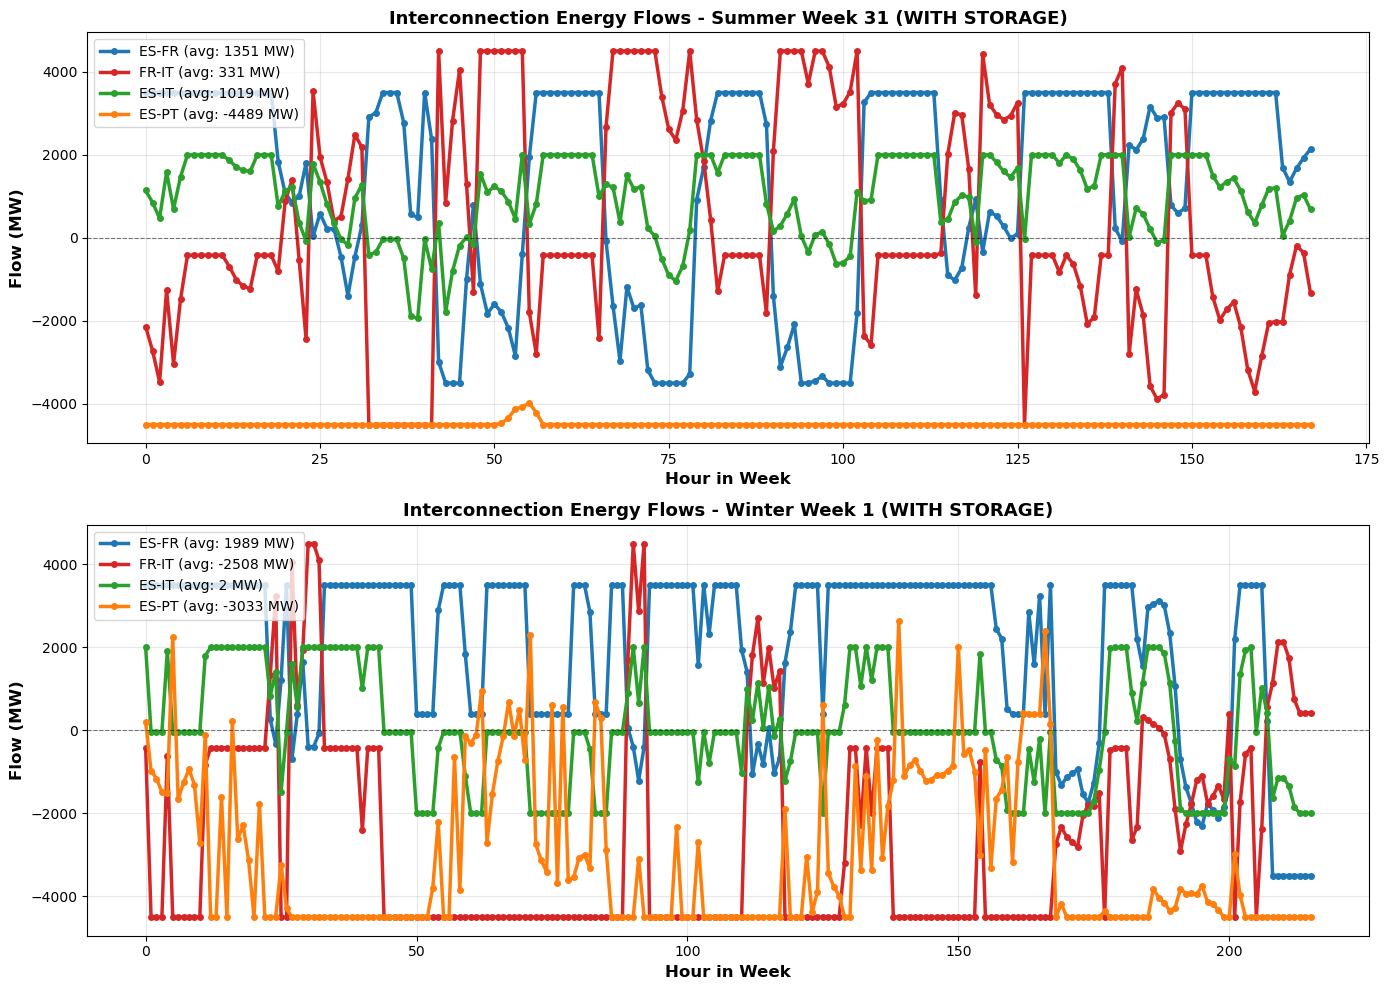


SUMMER WEEK FLOW STATISTICS (WITH STORAGE):
ES->FR: avg=  1351.1 MW | min= -3500.0 MW | max=  3500.0 MW
ES->IT: avg=  1019.0 MW | min= -1939.9 MW | max=  2000.0 MW
ES->PT: avg= -4489.3 MW | min= -4500.0 MW | max= -3976.4 MW
FR->IT: avg=   331.3 MW | min= -4500.0 MW | max=  4500.0 MW

WINTER WEEK FLOW STATISTICS (WITH STORAGE):
ES->FR: avg=  1988.9 MW | min= -3500.0 MW | max=  3500.0 MW
ES->IT: avg=     2.0 MW | min= -2000.0 MW | max=  2000.0 MW
ES->PT: avg= -3033.0 MW | min= -4500.0 MW | max=  2637.1 MW
FR->IT: avg= -2508.3 MW | min= -4500.0 MW | max=  4500.0 MW



In [20]:
# =====================
# INTERCONNECTION FLOWS: SUMMER & WINTER WEEKS (WITH STORAGE)
# =====================

print("\n" + "="*70)
print("6. INTERCONNECTION ENERGY FLOWS - SUMMER & WINTER (WITH STORAGE)")
print("="*70)

# Get power flows from optimization result
if not result_multi_storage.power_flows.empty:
    flows_df = result_multi_storage.power_flows.copy()
    
    # Map hour to date
    network_snapshots = result_multi_storage.network.snapshots
    flows_df['datetime'] = flows_df['time'].map(lambda h: network_snapshots[h] if h < len(network_snapshots) else None)
    flows_df['week'] = flows_df['datetime'].dt.isocalendar().week
    
    # Select random summer and winter weeks
    summer_weeks = [w for w in flows_df['week'].unique() if 22 <= w <= 35]
    winter_weeks = [w for w in flows_df['week'].unique() if 1 <= w <= 10]
    
    summer_week = np.random.choice(summer_weeks) if summer_weeks else summer_weeks[0]
    winter_week = np.random.choice(winter_weeks) if winter_weeks else winter_weeks[0]
    
    # Extract flows for selected weeks
    summer_flows = flows_df[flows_df['week'] == summer_week].copy()
    winter_flows = flows_df[flows_df['week'] == winter_week].copy()
    
    print(f"\nSummer Week: {summer_week} (starting {summer_flows['datetime'].min()})")
    print(f"Winter Week: {winter_week} (starting {winter_flows['datetime'].min()})")
    
    # Calculate averages for legend
    summer_summary = summer_flows.groupby(['from', 'to'])['flow_mw'].mean().reset_index()
    winter_summary = winter_flows.groupby(['from', 'to'])['flow_mw'].mean().reset_index()
    
    # Create visualization with 2x1 subplots
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Get unique interconnections
    interconnections_list = [(row['from'], row['to']) for _, row in flows_df[['from', 'to']].drop_duplicates().iterrows()]
    colors_flow = {'ES-FR': '#1f77b4', 'ES-PT': '#ff7f0e', 'ES-IT': '#2ca02c', 'FR-IT': '#d62728', 'PT-IT': '#9467bd'}
    
    # ---- SUMMER WEEK PLOT ----
    ax = axes[0]
    for from_c, to_c in interconnections_list:
        summer_route = summer_flows[(summer_flows['from'] == from_c) & (summer_flows['to'] == to_c)]
        if not summer_route.empty:
            route_name = f"{from_c}-{to_c}"
            color = colors_flow.get(route_name, 'gray')
            
            # Get average for this route
            avg_flow = summer_summary[(summer_summary['from'] == from_c) & (summer_summary['to'] == to_c)]['flow_mw'].values
            avg_label = f"{route_name} (avg: {avg_flow[0]:.0f} MW)" if len(avg_flow) > 0 else route_name
            
            ax.plot(range(len(summer_route)), summer_route['flow_mw'].values, 
                   marker='o', label=avg_label, linewidth=2.5, color=color, markersize=4)
    
    ax.set_xlabel('Hour in Week', fontsize=12, fontweight='bold')
    ax.set_ylabel('Flow (MW)', fontsize=12, fontweight='bold')
    ax.set_title(f'Interconnection Energy Flows - Summer Week {summer_week} (WITH STORAGE)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # ---- WINTER WEEK PLOT ----
    ax = axes[1]
    for from_c, to_c in interconnections_list:
        winter_route = winter_flows[(winter_flows['from'] == from_c) & (winter_flows['to'] == to_c)]
        if not winter_route.empty:
            route_name = f"{from_c}-{to_c}"
            color = colors_flow.get(route_name, 'gray')
            
            # Get average for this route
            avg_flow = winter_summary[(winter_summary['from'] == from_c) & (winter_summary['to'] == to_c)]['flow_mw'].values
            avg_label = f"{route_name} (avg: {avg_flow[0]:.0f} MW)" if len(avg_flow) > 0 else route_name
            
            ax.plot(range(len(winter_route)), winter_route['flow_mw'].values, 
                   marker='o', label=avg_label, linewidth=2.5, color=color, markersize=4)
    
    ax.set_xlabel('Hour in Week', fontsize=12, fontweight='bold')
    ax.set_ylabel('Flow (MW)', fontsize=12, fontweight='bold')
    ax.set_title(f'Interconnection Energy Flows - Winter Week {winter_week} (WITH STORAGE)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(f'./Plots/6_Interconnection_flows_summer_winter_WITH_STORAGE.png', dpi=150, bbox_inches='tight')
    print("\n✓ Interconnection flows plot (with storage) saved to './Plots/6_Interconnection_flows_summer_winter_WITH_STORAGE.png'")
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*70}")
    print("SUMMER WEEK FLOW STATISTICS (WITH STORAGE):")
    print(f"{'='*70}")
    for _, row in summer_summary.iterrows():
        print(f"{row['from']}->{row['to']}: avg={row['flow_mw']:>8.1f} MW", end="")
        route_data = summer_flows[(summer_flows['from'] == row['from']) & (summer_flows['to'] == row['to'])]
        print(f" | min={route_data['flow_mw'].min():>8.1f} MW | max={route_data['flow_mw'].max():>8.1f} MW")
    
    print(f"\n{'='*70}")
    print("WINTER WEEK FLOW STATISTICS (WITH STORAGE):")
    print(f"{'='*70}")
    for _, row in winter_summary.iterrows():
        print(f"{row['from']}->{row['to']}: avg={row['flow_mw']:>8.1f} MW", end="")
        route_data = winter_flows[(winter_flows['from'] == row['from']) & (winter_flows['to'] == row['to'])]
        print(f" | min={route_data['flow_mw'].min():>8.1f} MW | max={route_data['flow_mw'].max():>8.1f} MW")
else:
    print("No interconnection flow data available for storage case.")

print("\n" + "="*70)


7. INTERACTIVE FOLIUM MAP WITH PIE CHART GENERATION MIX (WITH STORAGE)

Adding country markers with pie charts to map...
Adding interconnection lines to map...

✓ Interactive Folium map with pie chart generation mix (WITH STORAGE)
✓ Features: Click on country markers to view detailed pie charts with percentages




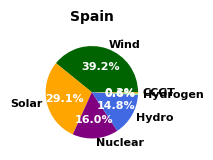
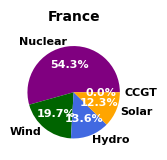
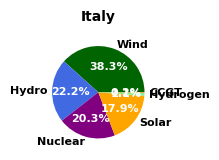
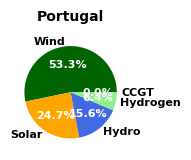

In [21]:
# =====================
# INTERACTIVE FOLIUM MAP WITH PIE CHART POPUPS (WITH STORAGE)
# =====================

import folium
from folium import plugins
from io import BytesIO
import base64

print("\n" + "="*70)
print("7. INTERACTIVE FOLIUM MAP WITH PIE CHART GENERATION MIX (WITH STORAGE)")
print("="*70)


# Define country coordinates (approximate centers) - shifted 1 degree to the right
country_coords = {
    'ES': (40.0, -2.7),    # Spain
    'FR': (46.2, 3.2),     # France
    'IT': (41.9, 13.6),    # Italy
    'PT': (39.4, -7.2),    # Portugal
}

# Define energy colors for generation
gen_colors = {
    "CCGT": "darkorange",
    "Coal": "darkgray",
    "Hydro": "royalblue",
    "Nuclear": "purple",
    "Solar": "orange",
    "Wind": "darkgreen",
    "Diesel": "red",
    "CHP": "saddlebrown",
}


# Create base map centered on Europe
center_lat = 43
center_lon = 5
folium_map_storage = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=4.5,
    tiles='OpenStreetMap'
)

# Extract generations for storage case to match non-storage structure
generations_by_country_tech_storage = {}
for country in ['ES', 'FR', 'IT', 'PT']:
    generations_by_country_tech_storage[country] = {}

# Get all generators from network and their generation time series
for gen_name, gen_row in result_multi_storage.network.generators.iterrows():
    if gen_name.startswith('gen_'):
        gen_name_clean = gen_name[4:]
        parts = gen_name_clean.split('_')
        if len(parts) >= 2:
            country = parts[0]
            tech = '_'.join(parts[1:])
            
            if country in generations_by_country_tech_storage:
                if gen_name in result_multi_storage.network.generators_t.p.columns:
                    annual_gen = result_multi_storage.network.generators_t.p[gen_name].sum()
                    generations_by_country_tech_storage[country][tech] = annual_gen

# Add storage dispatch data
for store_name, store_row in result_multi_storage.network.storage_units.iterrows():
    if 'battery' in store_name.lower():
        for country in ['ES', 'FR', 'IT', 'PT']:
            if country in store_name:
                if store_name in result_multi_storage.network.storage_units_t.p_dispatch.columns:
                    annual_dispatch = result_multi_storage.network.storage_units_t.p_dispatch[store_name].sum()
                    generations_by_country_tech_storage[country]['Battery'] = annual_dispatch
                break
    elif 'hydrogen' in store_name.lower():
        for country in ['ES', 'FR', 'IT', 'PT']:
            if country in store_name:
                if store_name in result_multi_storage.network.storage_units_t.p_dispatch.columns:
                    annual_dispatch = result_multi_storage.network.storage_units_t.p_dispatch[store_name].sum()
                    generations_by_country_tech_storage[country]['Hydrogen'] = annual_dispatch
                break

# Generate and add pie chart markers to map
def create_pie_chart_image(country_data, country_name, size=150, dpi=100):
    """Create a pie chart image from generation data"""
    fig, ax = plt.subplots(figsize=(size/dpi, size/dpi), dpi=dpi)
    
    # Prepare data
    labels = []
    sizes = []
    colors_list = []
    
    gen_colors = {
        'Wind': 'darkgreen',
        'Solar': 'orange',
        'Hydro': 'royalblue',
        'CCGT': 'darkorange',
        'Coal': 'darkred',
        'Nuclear': 'purple',
        'Diesel': 'red',
        'Battery': 'cyan',
        'Hydrogen': 'lightgreen'
    }
    
    for tech, value in sorted(country_data.items(), key=lambda x: x[1], reverse=True):
        if value > 0:
            labels.append(tech)
            sizes.append(value)
            colors_list.append(gen_colors.get(tech, 'lightgray'))
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels,
        colors=colors_list,
        autopct='%1.1f%%',
        textprops={'fontsize': 8, 'weight': 'bold'}
    )
    
    # Styling
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title(country_name, fontsize=10, fontweight='bold', pad=10)
    
    # Save to base64
    buffer = BytesIO()
    plt.savefig(buffer, format='png', bbox_inches='tight', transparent=False, dpi=dpi)
    buffer.seek(0)
    plt.close(fig)
    
    return base64.b64encode(buffer.read()).decode()

# Get available countries
available_countries = [c for c in country_coords.keys() 
                      if c in generations_by_country_tech_storage 
                      and sum(generations_by_country_tech_storage[c].values()) > 0]

country_names_full = {'ES': 'Spain', 'FR': 'France', 'IT': 'Italy', 'PT': 'Portugal'}
country_colors_map = {'ES': '#FF6B6B', 'FR': '#4ECDC4', 'IT': '#45B7D1', 'PT': '#FFA07A'}

# Add markers with embedded pie charts
print("\nAdding country markers with pie charts to map...")
for country in available_countries:
    lat, lon = country_coords[country]
    gen_data = generations_by_country_tech_storage[country]
    total_gen = sum(gen_data.values())
    
    if total_gen == 0:
        continue
    
    # Create pie chart image
    pie_img_base64 = create_pie_chart_image(gen_data, country_names_full[country])
    
    # Create popup HTML with pie chart
    popup_html = f"""
    <div style="width: 300px; text-align: center; font-family: Arial;">
        <h3 style="margin: 10px 0; color: #333;">{country_names_full[country]} ({country}) - WITH STORAGE</h3>
        <img src="data:image/png;base64,{pie_img_base64}" style="width: 280px; height: 280px;">
        <p style="margin: 10px 0; font-size: 12px; color: #666;">
            <b>Total Generation:</b> {total_gen/1e6:.2f} TWh/year
        </p>
        <table style="width: 100%; margin: 10px 0; font-size: 11px; border-collapse: collapse;">
            <tr style="background-color: #f0f0f0;">
                <th style="border: 1px solid #ddd; padding: 5px;">Technology</th>
                <th style="border: 1px solid #ddd; padding: 5px;">GWh</th>
                <th style="border: 1px solid #ddd; padding: 5px;">%</th>
            </tr>
    """
    
    for tech, val in sorted(gen_data.items(), key=lambda x: x[1], reverse=True):
        pct = 100 * val / total_gen if total_gen > 0 else 0
        popup_html += f"""
            <tr>
                <td style="border: 1px solid #ddd; padding: 5px; text-align: left;">{tech}</td>
                <td style="border: 1px solid #ddd; padding: 5px;">{val/1e3:.1f}</td>
                <td style="border: 1px solid #ddd; padding: 5px;">{pct:.1f}%</td>
            </tr>
        """
    
    popup_html += """
        </table>
    </div>
    """
    
    # Add marker to map
    folium.CircleMarker(
        location=[lat, lon],
        radius=25,
        popup=folium.Popup(popup_html, max_width=350),
        color=country_colors_map[country],
        fill=True,
        fillColor=country_colors_map[country],
        fillOpacity=0.8,
        weight=3,
        opacity=0.9
    ).add_to(folium_map_storage)
    
    # Add country label
    folium.Marker(
        location=[lat, lon],
        popup=f"{country_names_full[country]} (WITH STORAGE)<br>Click marker for details",
        icon=folium.Icon(icon='info-sign', prefix='glyphicon'),
    ).add_to(folium_map_storage)

# Draw interconnection links
print("Adding interconnection lines to map...")
for from_c, to_c in interconnections_list:
    if from_c in country_coords and to_c in country_coords:
        lat1, lon1 = country_coords[from_c]
        lat2, lon2 = country_coords[to_c]
        
        folium.PolyLine(
            locations=[[lat1, lon1], [lat2, lon2]],
            color='#2E5090',
            weight=3,
            opacity=0.6,
            popup=f"{from_c} ↔ {to_c}"
        ).add_to(folium_map_storage)

# Display map in notebook
print(f"\n✓ Interactive Folium map with pie chart generation mix (WITH STORAGE)")
print(f"✓ Features: Click on country markers to view detailed pie charts with percentages")
print("\n" + "="*70)

folium_map_storage


8. GENERATION WEEK FOR ALL COUNTRIES WITH STORAGE
   (Shows generation, storage dispatch, and transmission inflows)



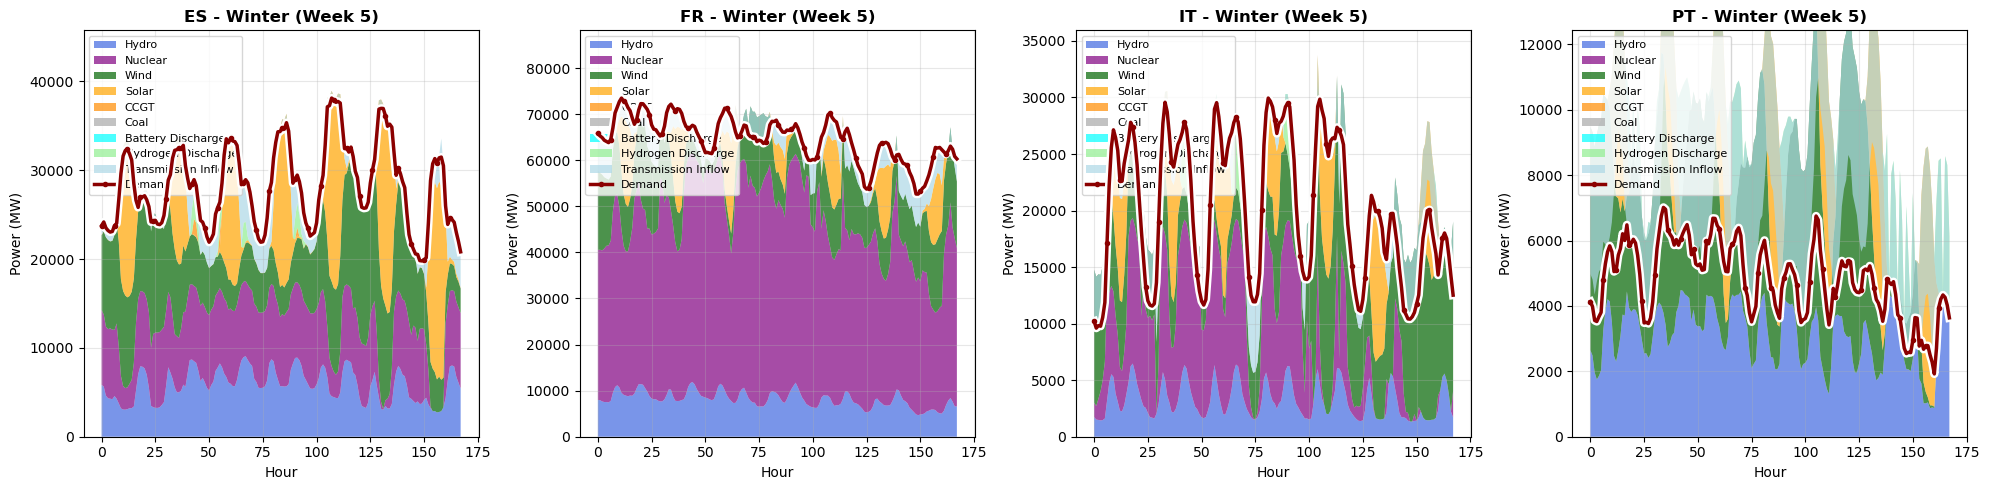


✓ Winter week plot (with storage) saved to './Plots/8_Generation_week_Winter_all_countries_WITH_STORAGE.png'



<Figure size 640x480 with 0 Axes>

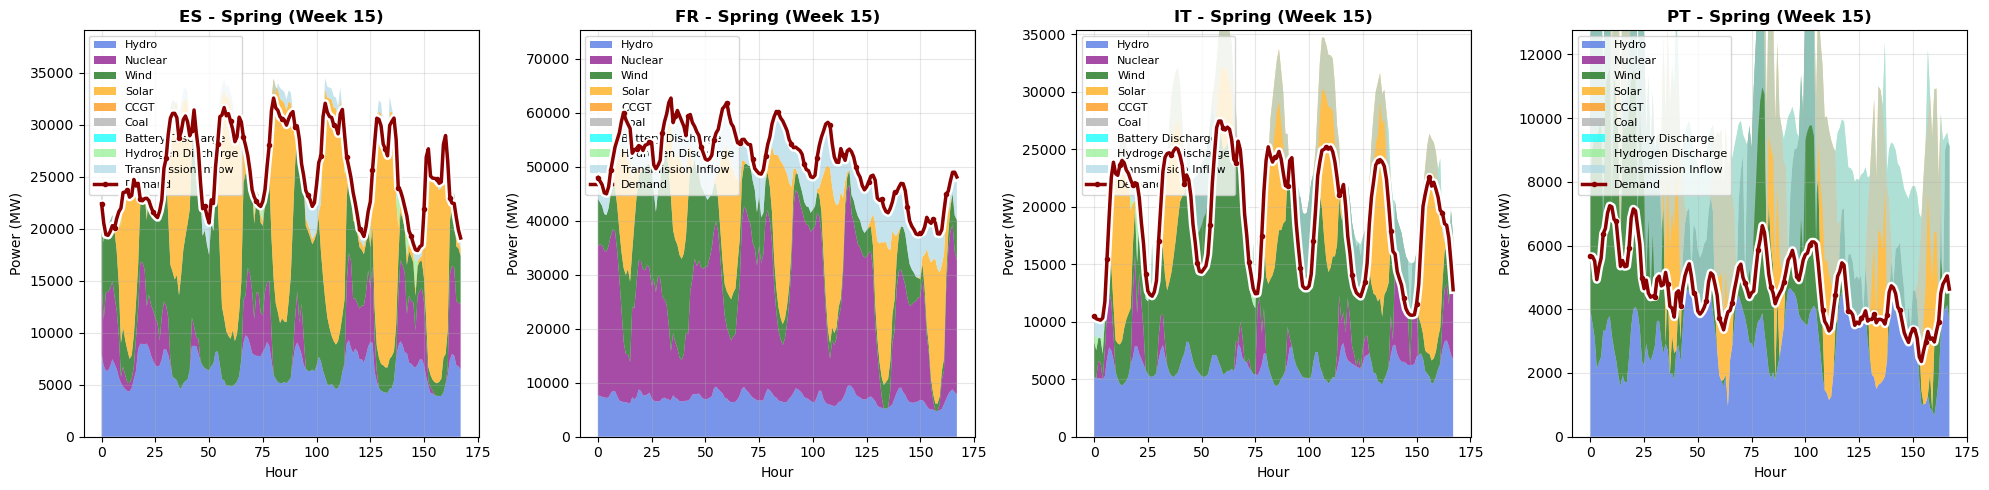


✓ Spring week plot (with storage) saved to './Plots/8_Generation_week_Spring_all_countries_WITH_STORAGE.png'



<Figure size 640x480 with 0 Axes>

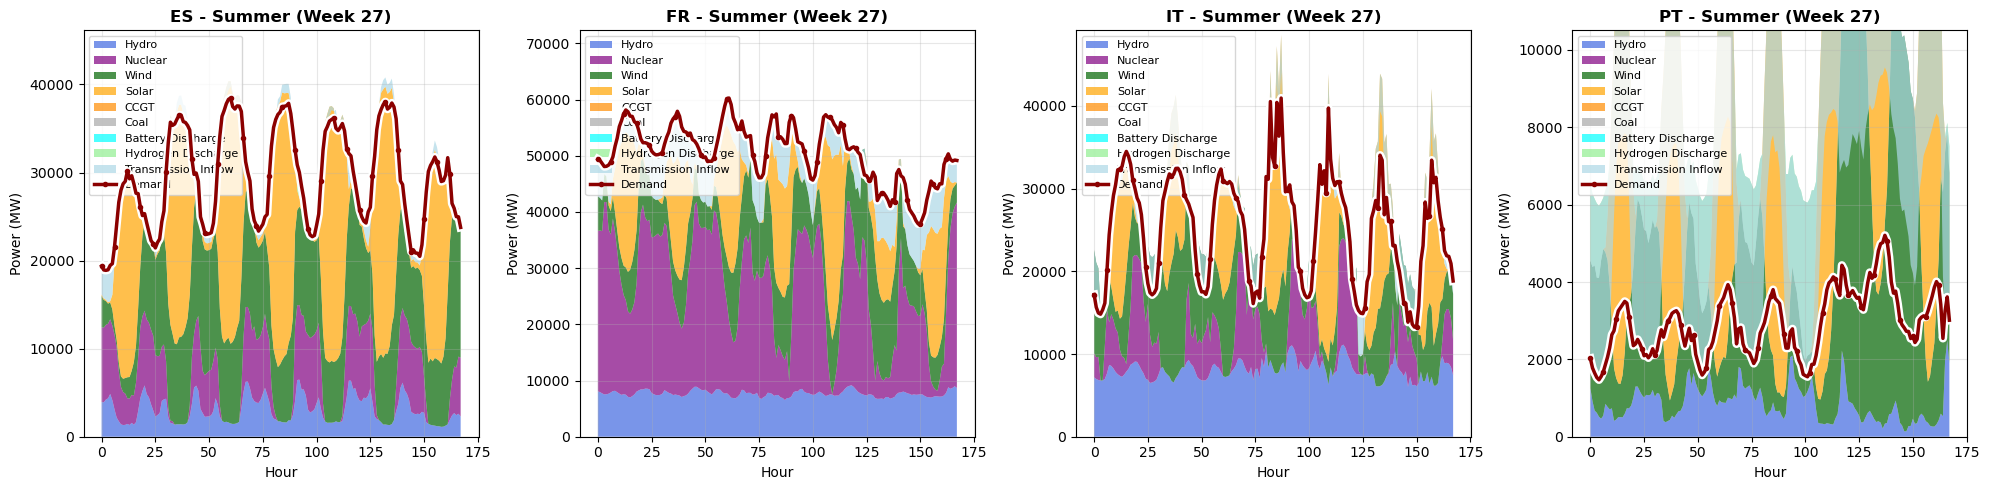


✓ Summer week plot (with storage) saved to './Plots/8_Generation_week_Summer_all_countries_WITH_STORAGE.png'



<Figure size 640x480 with 0 Axes>

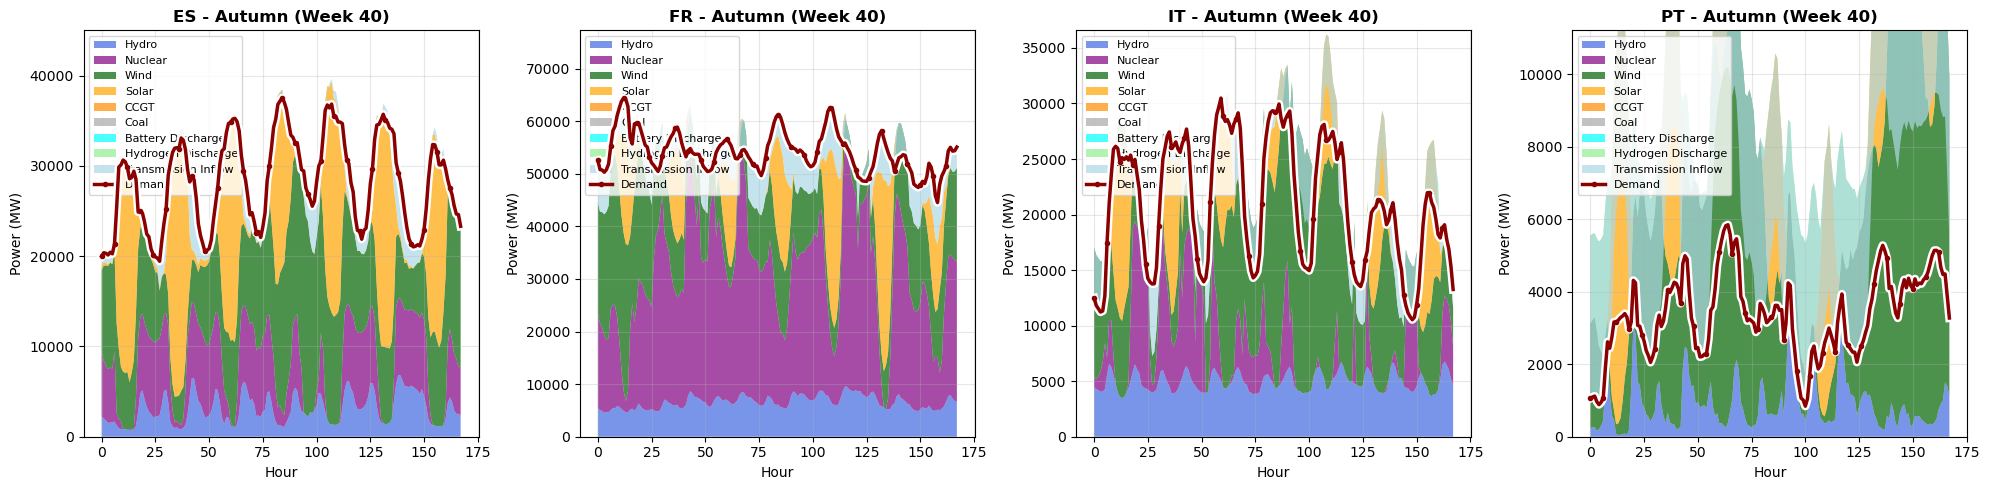


✓ Autumn week plot (with storage) saved to './Plots/8_Generation_week_Autumn_all_countries_WITH_STORAGE.png'


<Figure size 640x480 with 0 Axes>

In [24]:
# =====================
# GENERATION WEEK - ALL COUNTRIES WITH STORAGE (DISPATCH & STORAGE CHARGING/DISCHARGING)
# =====================

print("\n" + "="*70)
print("8. GENERATION WEEK FOR ALL COUNTRIES WITH STORAGE")
print("   (Shows generation, storage dispatch, and transmission inflows)")
print("="*70)

# Define representative weeks for all countries
representative_weeks = {
    'Winter': 5,
    'Spring': 15,
    'Summer': 27,
    'Autumn': 40
}

# Get network and extract data
network = result_multi_storage.network
countries_list = ['ES', 'FR', 'IT', 'PT']

# Map technologies to colors
color_map = {
    'Wind': 'darkgreen',
    'Solar': 'orange',
    'Hydro': 'royalblue',
    'CCGT': 'darkorange',
    'Coal': 'darkgray',
    'Nuclear': 'purple'
}

# Create figures for each season
for season, week_num in representative_weeks.items():
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    week_start = (week_num - 1) * 168
    week_end = week_start + 168
    
    for idx, country in enumerate(countries_list):
        # Get generation data for this country
        generators = network.generators[network.generators['bus'].str.contains(country, na=False)]
        
        # Initialize plot data
        plot_data = {}
        
        # Collect generation by technology for this country
        for gen_idx, gen in generators.iterrows():
            gen_id = gen.name
            gen_name_lower = str(gen_id).lower()
            tech = None
            
            # Map generator name to technology
            if 'wind' in gen_name_lower:
                tech = 'Wind'
            elif 'solar' in gen_name_lower:
                tech = 'Solar'
            elif 'hydro' in gen_name_lower or 'run' in gen_name_lower or 'reservoir' in gen_name_lower:
                tech = 'Hydro'
            elif 'nuclear' in gen_name_lower:
                tech = 'Nuclear'
            elif 'ccgt' in gen_name_lower or 'gas' in gen_name_lower:
                tech = 'CCGT'
            elif 'coal' in gen_name_lower:
                tech = 'Coal'
            
            if tech and tech in color_map:
                gen_data = network.generators_t.p[gen_id].iloc[week_start:week_end].values
                if tech not in plot_data:
                    plot_data[tech] = gen_data.copy()
                else:
                    plot_data[tech] += gen_data
        
        # Add storage dispatch (discharging) for this country
        # Battery discharge
        for store_name, store_row in network.storage_units.iterrows():
            if 'battery' in store_name.lower() and country in store_name:
                if store_name in network.storage_units_t.p_dispatch.columns:
                    battery_dispatch = network.storage_units_t.p_dispatch[store_name].iloc[week_start:week_end].values
                    if 'Battery Discharge' not in plot_data:
                        plot_data['Battery Discharge'] = battery_dispatch.copy()
                    else:
                        plot_data['Battery Discharge'] += battery_dispatch
        
        # Hydrogen discharge
        for store_name, store_row in network.storage_units.iterrows():
            if 'hydrogen' in store_name.lower() and country in store_name:
                if store_name in network.storage_units_t.p_dispatch.columns:
                    hydrogen_dispatch = network.storage_units_t.p_dispatch[store_name].iloc[week_start:week_end].values
                    if 'Hydrogen Discharge' not in plot_data:
                        plot_data['Hydrogen Discharge'] = hydrogen_dispatch.copy()
                    else:
                        plot_data['Hydrogen Discharge'] += hydrogen_dispatch
        
        # Get transmission line inflows to this country
        lines = network.lines
        line_inflows = np.zeros(168)
        
        for line_idx, line in lines.iterrows():
            bus0 = line['bus0']
            bus1 = line['bus1']
            
            # Check if line is importing to this country
            if country in bus1 and country not in bus0:
                # Power flowing into country (bus1)
                line_inflows += network.lines_t.p0[line_idx].iloc[week_start:week_end].values
            elif country in bus0 and country not in bus1:
                # Power flowing out of country (bus0) - negative inflow
                line_inflows -= network.lines_t.p0[line_idx].iloc[week_start:week_end].values
        
        # Add transmission inflows to plot data (only if non-zero)
        if np.any(line_inflows != 0):
            plot_data['Transmission Inflow'] = line_inflows
        
        # Get demand for this country
        loads = network.loads[network.loads['bus'].str.contains(country, na=False)]
        demand = np.zeros(168)
        for load_idx, load in loads.iterrows():
            demand += network.loads_t.p[load.name].iloc[week_start:week_end].values
        
        # Prepare data for stacked area plot
        ax = axes[idx]
        x = np.arange(168)
        
        # Sort plot_data for consistent stacking (storage at bottom)
        ordered_techs = ['Hydro', 'Nuclear', 'Wind', 'Solar', 'CCGT', 'Coal', 
                        'Battery Discharge', 'Hydrogen Discharge', 'Transmission Inflow']
        techs_to_plot = [t for t in ordered_techs if t in plot_data]
        colors = []
        plot_arrays = []
        
        for tech in techs_to_plot:
            plot_arrays.append(plot_data[tech])
            if tech == 'Transmission Inflow':
                colors.append('lightblue')
            elif tech == 'Battery Discharge':
                colors.append('cyan')
            elif tech == 'Hydrogen Discharge':
                colors.append('lightgreen')
            else:
                colors.append(color_map.get(tech, 'gray'))
        
        # Stacked area plot
        ax.stackplot(
            x,
            *plot_arrays,
            labels=techs_to_plot,
            colors=colors,
            alpha=0.7,
            zorder=1
        )
        
        # Plot demand line on top
        ax.plot(
            x,
            demand,
            color='white',
            linewidth=6,
            zorder=10
        )
        
        ax.plot(
            x,
            demand,
            color='darkred',
            linewidth=2.5,
            marker='o',
            markersize=3,
            markevery=6,
            label='Demand',
            zorder=11
        )
        
        ax.set_title(f"{country} - {season} (Week {week_num})",
                    fontsize=12, fontweight='bold')
        ax.set_ylabel('Power (MW)', fontsize=10)
        ax.set_xlabel('Hour', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Calculate y-limit based on the maximum of the stacked sum
        if plot_arrays:
            max_stack = np.sum(plot_arrays, axis=0).max()
            max_y = max(max_stack * 1.1, demand.max() * 1.2)
        else:
            max_y = demand.max() * 1.2
        ax.set_ylim(0, max_y)
        

        ax.legend(loc='upper left', fontsize=8, ncol=1)
    print("\n" + "="*70)

    

    plt.tight_layout()    
    plt.show()

    plt.savefig(f'./Plots/8_Generation_week_{season}_all_countries_WITH_STORAGE.png', dpi=150, bbox_inches='tight')    
    print(f"\n✓ {season} week plot (with storage) saved to './Plots/8_Generation_week_{season}_all_countries_WITH_STORAGE.png'")


9. MULTI-COUNTRY INTERCONNECTIONS MAP WITH OPTIMIZED GENERATION MIX (WITH STORAGE)

Country-wise Optimized Annual GENERATION by Technology (MWh) - WITH STORAGE:

ES: Total Generation = 242544.57 GWh
  Wind                : 94966.01 GWh ( 39.2%)
  Solar               : 70595.29 GWh ( 29.1%)
  Nuclear             : 38840.41 GWh ( 16.0%)
  Hydro               : 35894.52 GWh ( 14.8%)
  Hydrogen            :  1404.51 GWh (  0.6%)
  CCGT                :   843.82 GWh (  0.3%)
  Coal                :     0.00 GWh (  0.0%)
  Battery             :     0.00 GWh (  0.0%)

FR: Total Generation = 474346.56 GWh
  Nuclear             : 257781.48 GWh ( 54.3%)
  Wind                : 93494.45 GWh ( 19.7%)
  Hydro               : 64567.68 GWh ( 13.6%)
  Solar               : 58303.12 GWh ( 12.3%)
  CCGT                :   199.83 GWh (  0.0%)
  Coal                :     0.00 GWh (  0.0%)
  Battery             :     0.00 GWh (  0.0%)
  Hydrogen            :     0.00 GWh (  0.0%)

IT: Total Generation = 2

<Figure size 2000x1400 with 0 Axes>

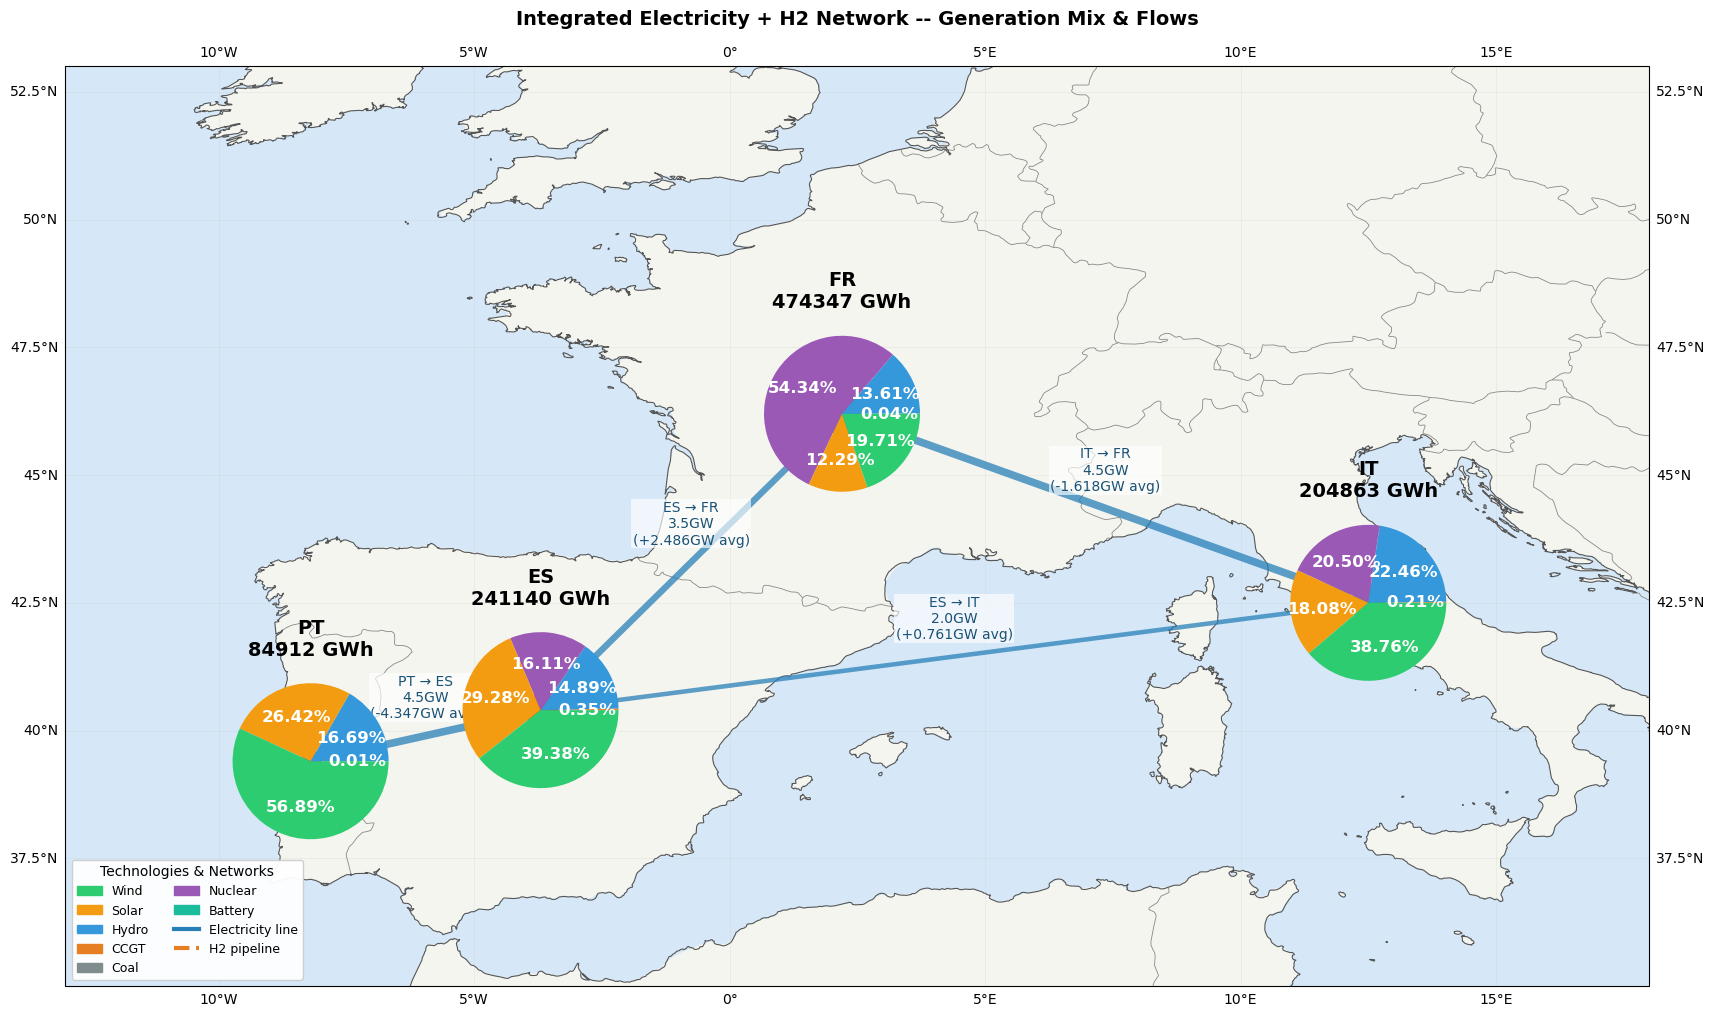

In [33]:
# =====================
# INTERCONNECTIONS MAP WITH OPTIMIZED GENERATION PIE CHART INSETS (WITH STORAGE)
# =====================

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

print("\n" + "="*70)
print("9. MULTI-COUNTRY INTERCONNECTIONS MAP WITH OPTIMIZED GENERATION MIX (WITH STORAGE)")
print("="*70)

# Get available countries with data
available_countries = [c for c in country_coords.keys() if c in generations_by_country_tech_storage and sum(generations_by_country_tech_storage[c].values()) > 0]

print("\nCountry-wise Optimized Annual GENERATION by Technology (MWh) - WITH STORAGE:")
print("="*70)
for country in available_countries:
    gen_dict = generations_by_country_tech_storage[country]
    total = sum(gen_dict.values())
    if total == 0:
        print(f"\n{country}: No generation data available")
        continue
    print(f"\n{country}: Total Generation = {total/1e3:.2f} GWh")
    for tech, val in sorted(gen_dict.items(), key=lambda x: x[1], reverse=True):
        pct = 100 * val / total if total > 0 else 0
        print(f"  {tech:20s}: {val/1e3:8.2f} GWh ({pct:5.1f}%)")

# Add storage information
print(f"\n{'-'*70}")
print("Storage Capacities (MW):")
print(f"{'-'*70}")
for country in ['ES', 'FR', 'IT', 'PT']:
    battery_cap = storage_capacities[country]['Battery']
    hydrogen_cap = storage_capacities[country]['Hydrogen']
    if battery_cap > 0 or hydrogen_cap > 0:
        print(f"{country}: Battery={battery_cap:,.0f} MW | Hydrogen={hydrogen_cap:,.0f} MW")
    else:
        print(f"{country}: No storage")

# Create figure with map
fig = plt.figure(figsize=(20, 14))
# PLOT5
# =====================================================================
# PLOT 5 -- GEOGRAPHIC MAP: ELECTRICITY + H2 NETWORKS
# Blue solid lines  = electricity interconnections (width ~ NTC)
# Orange dashed lines = H2 pipelines (width ~ H2 capacity)
# Pie chart insets  = annual generation mix per country
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

res     = result_multi_storage
network = res.network
COUNTRIES = res.countries

COORDS = {'ES': (40.4, -3.7), 'FR': (46.2,  2.2),
          'IT': (42.5, 12.5), 'PT': (39.4, -8.2)}

TECH_COLORS = {
    'Wind': '#2ecc71', 'Solar': '#f39c12', 'Hydro': '#3498db',
    'CCGT': '#e67e22', 'Coal': '#7f8c8d', 'Nuclear': '#9b59b6',
    'Battery': '#1abc9c',
}
COUNTRY_COLORS = {'ES': '#c0392b', 'FR': '#2980b9', 'IT': '#27ae60', 'PT': '#8e44ad'}

_gen_df  = network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

# Annual generation per country per tech
annual_gen = {c: {} for c in COUNTRIES}
for gen_name in _gen_df.index:
    for c in COUNTRIES:
        if gen_name.startswith(f'gen_{c}_'):
            tech = gen_name.replace(f'gen_{c}_', '')
            if gen_name in network.generators_t.p.columns:
                annual_gen[c][tech] = network.generators_t.p[gen_name].sum()

# Interconnection NTC (MW) and H2 pipeline capacities (MW_H2)
ELEC_LINES = [('ES','FR',3500), ('FR','IT',4500), ('ES','IT',2000), ('ES','PT',4500)]
H2_CAPS = {}
for name, row in network.links.iterrows():
    if name.startswith('h2_pipe_'):
        parts = name.split('_')
        from_c, to_c = parts[2], parts[3]
        H2_CAPS[(from_c, to_c)] = row['p_nom']

# Mean hourly flows
elec_net = {(f, t): grp['flow_mw'].mean()
            for (f, t), grp in res.power_flows.groupby(['from','to'])}

# Print interconnection flow information
print("\n" + "="*70)
print("ELECTRICITY INTERCONNECTION FLOWS (Average Hourly, MW):")
print("="*70)
print("\nFlow Convention: Positive = Left→Right | Negative = Right←Left")
print(f"{'Interconnection':<15} {'NTC':<10} {'Avg Flow':<15} {'Direction':<20}")
print("-" * 60)

for from_c, to_c, ntc in ELEC_LINES:
    flow_fwd = elec_net.get((from_c, to_c), 0)
    flow_rev = elec_net.get((to_c, from_c), 0)
    net_flow = flow_fwd - flow_rev
    
    if abs(net_flow) > 0.1:
        if net_flow > 0:
            direction = f"→ {from_c}→{to_c}"
        else:
            direction = f"→ {to_c}→{from_c}"
        flow_display = f"{abs(net_flow):.0f} MW"
    else:
        direction = "Balanced"
        flow_display = "~0 MW"
    
    print(f"{from_c}-{to_c:<11s} {ntc/1e3:>8.1f}GW {flow_display:>14s} {direction:<20s}")

print("-" * 60)
print("\nNote: Positive flow means energy moves in the POSITIVE direction (left to right)")
print("      Negative flow means energy moves in REVERSE direction (right to left)")

if HAS_CARTOPY:
    proj = ccrs.PlateCarree()
    fig  = plt.figure(figsize=(18, 13))
    ax   = fig.add_axes([0.05, 0.05, 0.88, 0.88], projection=proj)
    ax.set_extent([-13, 18, 35, 53], crs=proj)
    ax.add_feature(cfeature.LAND,   facecolor='#f5f5f0')
    ax.add_feature(cfeature.OCEAN,  facecolor='#d6e8f7')
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='#888')
    ax.coastlines(resolution='10m', linewidth=0.8, color='#555')
    ax.gridlines(draw_labels=True, alpha=0.2, linewidth=0.5)

    # Electricity lines (blue solid, width ~ NTC) with directional labels
    for from_c, to_c, ntc in ELEC_LINES:
        if from_c not in COORDS or to_c not in COORDS: continue
        lat1, lon1 = COORDS[from_c]; lat2, lon2 = COORDS[to_c]
        lw  = 1.5 + 4 * ntc / 4500
        flow_fwd = elec_net.get((from_c, to_c), 0)
        flow_rev = elec_net.get((to_c, from_c), 0)
        net_flow = flow_fwd - flow_rev
        
        # Determine direction based on net flow
        if net_flow > 0:
            direction_str = f"{from_c} → {to_c}"
        else:
            direction_str = f"{to_c} → {from_c}"
        
        ax.plot([lon1, lon2], [lat1, lat2], color='#2980b9', lw=lw,
                alpha=0.75, transform=proj, zorder=3)
        mx, my = (lon1+lon2)/2, (lat1+lat2)/2
        ax.text(mx, my+0.35, f'{direction_str}\n{ntc/1e3:.1f}GW\n({net_flow/1e3:+.3f}GW avg)',
                transform=proj, fontsize=10, ha='center', color='#1a5276',
                bbox=dict(facecolor='white', alpha=0.65, pad=1, edgecolor='none'))

    # Country nodes
    for c in COUNTRIES:
        if c not in COORDS: continue
        lat, lon = COORDS[c]
        total = sum(_gen_df.loc[n, _cap_col]
                    for n in _gen_df.index if n.startswith(f'gen_{c}_'))
        ms = 12 + 22 * total / 200e3
        ax.plot(lon, lat, 'o', markersize=ms, color=COUNTRY_COLORS.get(c,'gray'),
                transform=proj, zorder=5, markeredgecolor='white', markeredgewidth=2)
        #ax.text(lon, lat+1.3, c, transform=proj, fontsize=13,
               # fontweight='bold', ha='center')

    # Pie chart insets at country nodes
    ax_pos = ax.get_position()
    LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -13, 18, 35, 53
    SZ = 0.15

    for c in COUNTRIES:
        if c not in COORDS or not annual_gen[c]: continue
        lat, lon = COORDS[c]
        rel_x = (lon - LON_MIN) / (LON_MAX - LON_MIN)
        rel_y = (lat - LAT_MIN) / (LAT_MAX - LAT_MIN)
        fx = ax_pos.x0 + rel_x * ax_pos.width  - SZ / 2
        fy = ax_pos.y0 + rel_y * ax_pos.height - SZ / 2
        ax_i = fig.add_axes([fx, fy, SZ, SZ])
        data = {t: v for t, v in annual_gen[c].items() if v > 0}
        if not data: continue
        _, _, auts = ax_i.pie(
            list(data.values()),
            colors=[TECH_COLORS.get(t,'#bdc3c7') for t in data],
            autopct='%3.2f%%', textprops={'fontsize': 8}
        )
        for at in auts:
            at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(12)
        gwh = sum(data.values()) / 1e3
        ax_i.set_title(f'{c}\n{gwh:.0f} GWh', fontsize=14, fontweight='bold')

    # Legend
    tech_p = [mpatches.Patch(color=TECH_COLORS.get(t,'gray'), label=t)
              for t in ['Wind','Solar','Hydro','CCGT','Coal','Nuclear','Battery']]
    el_ln  = mlines.Line2D([], [], color='#2980b9', lw=3, label='Electricity line')
    h2_ln  = mlines.Line2D([], [], color='#e67e22', lw=3, ls='--', label='H2 pipeline')
    ax.legend(handles=tech_p + [el_ln, h2_ln], loc='lower left',
              fontsize=9, framealpha=0.95, ncol=2,
              title='Technologies & Networks', title_fontsize=10)
    ax.set_title('Integrated Electricity + H2 Network -- Generation Mix & Flows',
                 fontsize=14, fontweight='bold', pad=15)

else:
    # Schematic fallback if cartopy not installed
    fig, ax = plt.subplots(figsize=(10, 8))
    POS = {'ES': (0.22, 0.38), 'FR': (0.52, 0.72), 'IT': (0.78, 0.40), 'PT': (0.06, 0.28)}
    for from_c, to_c, ntc in ELEC_LINES:
        x1,y1 = POS[from_c]; x2,y2 = POS[to_c]
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2))
    for (from_c, to_c), cap in H2_CAPS.items():
        x1,y1 = POS.get(from_c,(0,0)); x2,y2 = POS.get(to_c,(0,0))
        ax.plot([x1,x2],[y1,y2], '--', color='#e67e22', lw=2, alpha=0.7)
    for c, (x,y) in POS.items():
        ax.text(x, y, c, ha='center', va='center', fontsize=18, fontweight='bold',
                color=COUNTRY_COLORS.get(c,'gray'),
                bbox=dict(boxstyle='circle,pad=0.5', facecolor='white', edgecolor='gray'))
    el_ln = mlines.Line2D([],[],color='#2980b9', label='Electricity lines')
    h2_ln = mlines.Line2D([],[],color='#e67e22', ls='--', label='H2 pipelines')
    ax.legend(handles=[el_ln, h2_ln], fontsize=11)
    ax.set_title('Integrated Network (schematic -- install cartopy for map)', fontsize=12)
    ax.axis('off')


plt.savefig('./Plots/9_Annual_electricity_mix_interconnections_map_WITH_STORAGE.png', dpi=200, bbox_inches='tight')
print("\n✓ Optimized interconnections map with generation pie insets (WITH STORAGE) saved to './Plots/9_Annual_electricity_mix_interconnections_map_WITH_STORAGE.png'")
plt.show()

print("\n" + "="*70)